# TableGuard 06B — View saved results / explicit new recording

**For your current problem: select `Python (TableGuard)` and choose Run All once. Leave `MODE = "view_saved"`.**

This notebook opens your completed recording folder **`20260912T235941Z_recording_0cd563`**. It prints the saved grasp results, checks the observation-manifest count and image references, and displays up to five saved images. It does not need to re-execute the robot, run regression tests, record more images, or create another configuration to show an existing result.

**Stop or finish any earlier running notebook cell before opening this one.** Reopen an idle kernel; do not run two recording workers concurrently.

### Why the uploaded copy was confusing
- All three code cells in the uploaded file have `execution_count: null` and empty `outputs`. That copy does not contain previously saved on-screen results; your local reports/images remain separate evidence.
- Its first cell still sets `RECORD_DATA = False` and creates a new output directory. Viewing saved results and starting a new trial were not separate actions.
- Its results cell relies on `GRASP_REPORT_PATH` set by the earlier execution cell. It does not independently open the completed recording you already have.

**This fixes the workflow and result display. It does not claim faster robot physics or a new successful grasp.** The original 06B robot worker and its 56-test regression suite are preserved byte-for-byte as text. No limits, contact checks, targets, success criteria, image resolution, or recording interval are changed.

No package installation, download, folder moving, or copying long code fragments is required. All displayed measurements and pixels are read from your own selected run; this notebook contains no fabricated experiment outputs.


## Load the tools — no simulation starts here
The large source is collapsed to avoid accidental fragment edits. Run this cell once.

In [1]:
"""Results-first workflow. View mode is read-only and never starts a worker."""
from pathlib import Path, PureWindowsPath
from datetime import datetime, timezone
import hashlib
import html
import io
import json
import os
import subprocess
import sys
import time
import uuid

from IPython.display import display, Image as NotebookImage, Markdown
from PIL import Image as PillowImage


def read_object(path, limit=16 * 1024 * 1024):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(str(path))
    if path.stat().st_size > limit:
        raise ValueError(f"Unexpectedly large JSON file: {path}")
    value = json.loads(path.read_text(encoding="utf-8-sig"))
    if not isinstance(value, dict):
        raise ValueError(f"Expected a JSON object in {path}")
    return value


def write_object(path, value):
    path = Path(path)
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(json.dumps(value, indent=2, allow_nan=False), encoding="utf-8")
    temp.replace(path)


def digest(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def artifact_path(run_dir, value):
    """Only resolve files within the explicitly selected evidence folder.

    Also handles a copied run folder whose reports retain the old absolute path.
    No files in other runs are substituted.
    """
    run_dir = Path(run_dir).resolve()
    if not isinstance(value, str) or not value:
        raise ValueError("Missing artifact filename")
    native = Path(value)
    if native.is_absolute():
        try:
            relative = native.resolve().relative_to(run_dir)
        except ValueError:
            parts = native.parts
            matches = [i for i, part in enumerate(parts) if part == run_dir.name]
            if not matches:
                raise ValueError(f"Artifact is not from this selected run: {value}")
            relative = Path(*parts[matches[-1] + 1:])
    elif PureWindowsPath(value).is_absolute():
        parts = PureWindowsPath(value).parts
        matches = [i for i, part in enumerate(parts) if part == run_dir.name]
        if not matches:
            raise ValueError(f"Artifact is not from this selected run: {value}")
        relative = Path(*parts[matches[-1] + 1:])
    else:
        relative = Path(*PureWindowsPath(value).parts)
    result = (run_dir / relative).resolve()
    if not result.is_relative_to(run_dir):
        raise ValueError(f"Artifact escapes selected run: {value}")
    return result


def show_tail(path, lines=15):
    path = Path(path)
    if not path.is_file():
        return
    with path.open("rb") as stream:
        stream.seek(max(0, path.stat().st_size - 12000))
        text = stream.read().decode("utf-8", errors="replace")
    print(f"\nLast {lines} lines of {path.name}:")
    print("\n".join(text.splitlines()[-lines:]))


def show_picture(path, title):
    """Display saved pixels; never call the simulator or a model."""
    path = Path(path)
    if not path.is_file():
        print(f"Missing image (not recreated): {path}")
        return False
    if path.stat().st_size > 25 * 1024 * 1024:
        print(f"Image is too large for inline preview; open locally: {path}")
        return False
    try:
        with PillowImage.open(path) as image:
            image = image.convert("RGB")
            image.thumbnail((720, 540))
            buffer = io.BytesIO()
            image.save(buffer, format="PNG")
        display(Markdown("### " + html.escape(title)))
        display(NotebookImage(data=buffer.getvalue(), format="png"))
        return True
    except (OSError, ValueError) as exc:
        print(f"Image could not be decoded: {path.name}: {exc}")
        return False


def inspect_manifest(run_dir, report, max_records=5000):
    count = report.get("recorded_observation_action_pairs", 0)
    value = report.get("observation_manifest")
    summary = {"manifest_rows": 0, "image_references": 0, "missing_images": [],
               "recording_files_checked": False, "messages": []}
    if not value:
        summary["messages"].append(
            "This report has no observation manifest; it may be a snapshots-only trial."
        )
        if count:
            summary["messages"].append("Report declares records but does not identify their manifest.")
        return summary, []
    manifest = artifact_path(run_dir, value)
    if not manifest.is_file():
        raise FileNotFoundError(f"Reported observation manifest is missing: {manifest}")
    if manifest.stat().st_size > 64 * 1024 * 1024:
        raise ValueError("Manifest exceeds the bounded inspection size (64 MiB).")
    records, seen_frames, previous_time = [], set(), -float("inf")
    with manifest.open(encoding="utf-8-sig") as stream:
        for line_number, line in enumerate(stream, start=1):
            if not line.strip():
                continue
            if len(records) >= max_records:
                raise ValueError(f"More than {max_records} records; bounded viewer stopped.")
            row = json.loads(line)
            if not isinstance(row, dict):
                raise ValueError(f"Non-object manifest row at line {line_number}")
            images = row.get("images")
            if not isinstance(images, dict) or not {"top", "right_wrist_cam"} <= images.keys():
                raise ValueError(f"Paired cameras are missing at manifest line {line_number}")
            frame = row.get("frame_id")
            if not isinstance(frame, int) or frame in seen_frames:
                raise ValueError(f"Invalid or duplicate frame ID at line {line_number}")
            stamp = row.get("time_s")
            if not isinstance(stamp, (int, float)) or not float("-inf") < stamp < float("inf") or stamp <= previous_time:
                raise ValueError(f"Invalid/non-increasing timestamp at line {line_number}")
            seen_frames.add(frame)
            previous_time = stamp
            for name in images.values():
                path = artifact_path(run_dir, name)
                summary["image_references"] += 1
                if not path.is_file():
                    summary["missing_images"].append(str(path))
            records.append(row)
    summary["manifest_rows"] = len(records)
    if count != len(records):
        summary["messages"].append(f"Report count {count!r} differs from manifest count {len(records)}.")
    if summary["missing_images"]:
        summary["messages"].append("Some image files are missing; they have not been reconstructed.")
    summary["recording_files_checked"] = bool(records and count == len(records) and not summary["messages"])
    return summary, records


def view_saved_run(run_dir, show_images=True):
    """Load existing evidence only. Never create a configuration or run a test."""
    start = time.monotonic()
    run_dir = Path(run_dir).resolve()
    print("VIEW SAVED RESULTS — no simulation, no regression rerun, no recording", flush=True)
    print("Selected run:", run_dir, flush=True)
    report_path = run_dir / "grasp_report.json"
    if not report_path.is_file():
        names = sorted(p.name for p in run_dir.iterdir()) if run_dir.is_dir() else []
        print("Report not found. Files present:", ", ".join(names[:25]) or "(folder missing or empty)")
        if names == ["grasp_config.json"]:
            print("SETUP ONLY: this folder has a configuration but no executed-trial report.")
        for log in ("regression.log", "grasp.log"):
            show_tail(run_dir / log)
        print("Select a completed run in RUN_NAME. No simulation has been started.")
        return {"status": "missing_report", "run": str(run_dir), "simulation_launched": False}
    report = read_object(report_path)
    print("\nSAVED GRASP SUMMARY", flush=True)
    keys = ("completed", "grasp_test_passed", "grasp_verified", "lift_verified", "release_verified",
            "physics_steps", "simulation_time_s", "recorded_observation_action_pairs", "graphics_error", "stops")
    for key in keys:
        print(f"{key}: {report.get(key, 'not recorded')}")
    timing_path = run_dir / "launcher_status.json"
    if timing_path.is_file():
        try:
            print("Full worker process wall time (s):", read_object(timing_path).get("full_process_wall_time_s", "not recorded"))
        except (ValueError, OSError) as exc:
            print("Launcher status could not be read:", exc)
    for title, field in (("MEASURED LIFT", "lift_measurements"), ("TABLE SUPPORT", "set_down_measurements"), ("MEASURED RELEASE", "release_measurements")):
        print("\n" + title)
        print(json.dumps(report.get(field, {}), indent=2))
    print("\nInspecting the saved observation manifest and image references...", flush=True)
    try:
        check, records = inspect_manifest(run_dir, report)
        print("Manifest rows:", check["manifest_rows"])
        print("Referenced image files:", check["image_references"])
        print("Missing image files:", len(check["missing_images"]))
        print("Basic recording file checks passed:", check["recording_files_checked"])
        for message in check["messages"]:
            print("NOTE:", message)
        for missing in check["missing_images"][:5]:
            print("Missing:", missing)
    except (ValueError, OSError, TypeError) as exc:
        check, records = {"recording_files_checked": False, "error": str(exc)}, []
        print("RECORDING INSPECTION ERROR:", exc)
    pictures_displayed = 0
    if show_images:
        snaps = report.get("snapshots", {})
        if not isinstance(snaps, dict):
            snaps = {}
        # Only a small number of saved images are decoded; no GIF encoding.
        for label in ("start", "lifted", "final"):
            value = snaps.get(label)
            if value:
                try:
                    pictures_displayed += int(show_picture(artifact_path(run_dir, value), label.title() + " — saved engineering snapshot"))
                except ValueError as exc:
                    print("Snapshot path rejected:", exc)
        if records:
            example = records[len(records) // 2]
            print(f"\nRecorded example: frame {example['frame_id']}, simulated t={example['time_s']:.3f} s")
            print("Instruction label:", example.get("instruction", "not recorded"))
            for camera in ("top", "right_wrist_cam"):
                pictures_displayed += int(show_picture(artifact_path(run_dir, example["images"][camera]), camera + " — saved pre-action observation"))
        if pictures_displayed == 0:
            print("No readable saved images available in this run; none were generated.")
    if report.get("stops") or report.get("grasp_test_passed") is not True:
        show_tail(run_dir / "grasp.log")
    print("\nDisplay preparation time (s):", round(time.monotonic() - start, 3))
    print("No new robot trial was launched. Source evidence was read, not changed.")
    print("This is an engineering demonstration, not trained-policy evaluation or complete table-setting.")
    return {"status": "displayed", "run": str(run_dir), "report": report, "recording": check,
            "pictures_displayed": pictures_displayed, "simulation_launched": False}


def stream_process(command, root, log_path, status_path, timeout_s, heartbeat_s=10):
    """Bounded child execution, live output, and cleanup on timeout/interruption."""
    if timeout_s <= 0 or heartbeat_s <= 0:
        raise ValueError("Timeout and heartbeat must be positive")
    env = os.environ.copy()
    env.update(PYTHONUTF8="1", PYTHONIOENCODING="utf-8", PYTHONUNBUFFERED="1")
    status = {"command": list(map(str, command)), "running": True, "timed_out": False,
              "interrupted": False, "returncode": None, "pid": None}
    start, proc = time.monotonic(), None
    write_object(status_path, status)
    try:
        with Path(log_path).open("x", encoding="utf-8") as writer:
            proc = subprocess.Popen(command, cwd=root, env=env, stdout=writer, stderr=subprocess.STDOUT)
            status["pid"] = proc.pid
            write_object(status_path, status)
            heartbeat = start
            with Path(log_path).open(encoding="utf-8", errors="replace") as reader:
                while True:
                    chunk = reader.read(65536)
                    if chunk:
                        print(chunk, end="", flush=True)
                    if proc.poll() is not None:
                        remainder = reader.read()
                        if remainder:
                            print(remainder, end="", flush=True)
                        break
                    elapsed = time.monotonic() - start
                    if elapsed > timeout_s:
                        status["timed_out"] = True
                        raise TimeoutError(f"Worker limit ({timeout_s}s) exceeded; log retained: {log_path}")
                    if time.monotonic() - heartbeat >= heartbeat_s:
                        obs = Path(log_path).parent / "observations"
                        jpeg_count = sum(1 for _ in obs.glob("*.jpg")) if obs.is_dir() else 0
                        print(f"[launcher] {elapsed:.1f}s elapsed; saved JPEGs: {jpeg_count}; worker active (not a convergence claim)", flush=True)
                        heartbeat = time.monotonic()
                    time.sleep(.1)
    except KeyboardInterrupt:
        status["interrupted"] = True
        raise
    finally:
        if proc is not None and proc.poll() is None:
            proc.terminate()
            try:
                proc.wait(timeout=5)
            except subprocess.TimeoutExpired:
                proc.kill()
                proc.wait(timeout=5)
        status.update(running=False, returncode=proc.returncode if proc is not None else None,
                      full_process_wall_time_s=time.monotonic() - start)
        write_object(status_path, status)
    return status


def new_recording(root, source_run):
    """Explicit new trial only. Original controller and all 56 tests are retained."""
    root, source_run = Path(root).resolve(), Path(source_run).resolve()
    if Path(sys.prefix).name.lower() != "tableguard":
        raise RuntimeError("New trials require the existing Python (TableGuard) kernel.")
    prior = read_object(source_run / "grasp_report.json")
    if (not all(prior.get(k) is True for k in ("completed", "grasp_test_passed", "grasp_verified", "lift_verified", "release_verified"))
            or prior.get("stops") or prior.get("source_scene_modified")):
        raise RuntimeError("Choose a passed, unchanged source trial before starting a recording trial.")
    config = read_object(source_run / "grasp_config.json")
    scene = Path(config["scene"])
    if not scene.is_file() or digest(scene) != config.get("scene_sha256"):
        raise RuntimeError("Source scene is missing or changed. No trial started.")
    for label, source, expected in (("worker", WORKER_SOURCE, EXPECTED_WORKER_SHA256), ("regression tests", TEST_SOURCE, EXPECTED_TEST_SHA256)):
        if hashlib.sha256(source.encode("utf-8")).hexdigest() != expected:
            raise RuntimeError(f"Embedded {label} changed or truncated. No trial started.")
        compile(source, f"<{label}>", "exec")
    # Prevent concurrent runs started by this corrected notebook.
    lock = root / "artifacts" / "cup_grasp_06b" / ".results_fixed_run.lock"
    token = uuid.uuid4().hex
    try:
        with lock.open("x", encoding="utf-8") as stream:
            json.dump({"token": token, "notebook_pid": os.getpid()}, stream)
    except FileExistsError:
        raise RuntimeError(f"A run lock exists. Do not start a duplicate. Confirm the previous worker stopped before removing only this lock: {lock}")
    run_dir = None
    try:
        run_dir = lock.parent / (datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_recording_" + uuid.uuid4().hex[:6])
        run_dir.mkdir(exist_ok=False)
        config = dict(config, record_data=True, output=str(run_dir), workflow_revision="results-first-v1")
        write_object(run_dir / "grasp_config.json", config)
        for name, text in (("grasp_worker.py", WORKER_SOURCE), ("regression_tests.py", TEST_SOURCE)):
            with (run_dir / name).open("x", encoding="utf-8", newline="\n") as stream:
                stream.write(text)
        print("NEW RECORDING TRIAL — existing runs preserved", flush=True)
        print("Output folder:", run_dir, flush=True)
        print("Saved configuration record_data:", read_object(run_dir / "grasp_config.json")["record_data"], flush=True)
        print("Running the original 56 portable regression checks...", flush=True)
        regression = stream_process([sys.executable, "-u", str(run_dir / "regression_tests.py"), str(run_dir / "grasp_worker.py")], root,
                                    run_dir / "regression.log", run_dir / "regression_launcher_status.json", 60)
        summary = read_object(run_dir / "regression_summary.json")
        if regression["returncode"] != 0 or summary.get("passed") is not True:
            raise RuntimeError(f"Regression checks failed. No robot trial launched. See {run_dir / 'regression.log'}")
        print("Starting the recording worker now...", flush=True)
        status = stream_process([sys.executable, "-u", str(run_dir / "grasp_worker.py"), str(run_dir / "grasp_config.json")], root,
                                run_dir / "grasp.log", run_dir / "launcher_status.json", 300)
        print("Worker process wall time (s):", round(status["full_process_wall_time_s"], 3))
        if status["returncode"] not in (0, 2):
            raise RuntimeError(f"Worker failed with exit {status['returncode']}; inspect {run_dir / 'grasp.log'}")
        if not (run_dir / "grasp_report.json").is_file():
            raise RuntimeError(f"No report produced; inspect {run_dir / 'grasp.log'}")
        return run_dir
    finally:
        try:
            if lock.is_file() and read_object(lock).get("token") == token:
                lock.unlink()
        finally:
            if run_dir is not None:
                print("Run evidence retained:", run_dir, flush=True)


def run_workflow(root, run_name, mode="view_saved"):
    if mode not in ("view_saved", "new_recording"):
        raise ValueError("MODE must be 'view_saved' or 'new_recording'.")
    root = Path(root).expanduser().resolve()
    if not root.is_dir():
        raise FileNotFoundError(f"Project folder not found: {root}")
    if not isinstance(run_name, str) or not run_name or Path(run_name).name != run_name or "/" in run_name or "\\" in run_name or run_name in (".", ".."):
        raise ValueError("RUN_NAME must identify one folder, not a path.")
    selected_run = root / "artifacts" / "cup_grasp_06b" / run_name
    if mode == "new_recording":
        selected_run = new_recording(root, selected_run)
    result = view_saved_run(selected_run)
    result["simulation_launched"] = mode == "new_recording"
    return result


# Original worker and original 56-test suite: preserved unchanged, NOT executed in view mode.
WORKER_SOURCE = '"""TableGuard 06B: carried-object scratch planning correction for the cup trial.\n\nThis is an engineering demonstration generator using simulator state, NOT a\ntrained policy, camera-based decision system, bimanual task, or challenge score.\nOnly SCRATCH planning state has positions assigned, including the predicted cup pose. EXECUTION advances via ctrl\nand mj_step. No equality weld, object teleportation, external lift force, or\ncollision disable is used. Source scene and prior evidence remain unchanged.\n"""\nfrom pathlib import Path\nimport csv\nimport hashlib\nimport json\nimport math\nimport os\nimport sys\nimport time\nimport traceback\nimport xml.etree.ElementTree as ET\n\nimport numpy as np\nfrom PIL import Image, ImageDraw\n\nJOINT_SUFFIXES = (\'shoulder_pan\',\'shoulder_lift\',\'elbow_flex\',\'wrist_flex\',\'wrist_roll\',\'gripper\')\nCOMMAND_SPEED = 0.35\nPOSITION_TOL = 0.0005\nAXIS_TOL_DEG = 2.0\nORIENTATION_WEIGHT = 0.08\nCONTACT_MIN_N = 0.02\nGRIPPER_TORQUE_CAP = 0.25\nPENETRATION_LIMIT = 0.003\nMAX_WALL_SECONDS = 240.0\n\n\ndef write_json(path, value):\n    path = Path(path)\n    tmp = path.with_suffix(path.suffix + \'.tmp\')\n    tmp.write_text(json.dumps(value, indent=2, allow_nan=False), encoding=\'utf-8\')\n    tmp.replace(path)\n\n\ndef digest(path):\n    return hashlib.sha256(Path(path).read_bytes()).hexdigest()\n\n\ndef normalize(vector):\n    vector = np.asarray(vector, dtype=float)\n    length = float(np.linalg.norm(vector))\n    if vector.shape != (3,) or not np.isfinite(vector).all() or length < 1e-10:\n        raise ValueError(\'A finite nonzero 3D vector is required\')\n    return vector / length\n\n\ndef skew(v):\n    x,y,z = v\n    return np.array([[0,-z,y],[z,0,-x],[-y,x,0]],dtype=float)\n\n\ndef smooth(s):\n    if not math.isfinite(float(s)):\n        raise ValueError(\'Non-finite interpolation parameter\')\n    x = float(np.clip(s,0,1))\n    return x*x*(3-2*x)\n\n\ndef solve_pose(evaluate, target, axis, seed, lo, hi, budget):\n    """Damped IK for a body-attached point and one tool axis; yaw is free."""\n    target, axis = np.asarray(target,dtype=float), normalize(axis)\n    q, lo, hi = [np.array(a,dtype=float,copy=True) for a in (seed,lo,hi)]\n    if (target.shape != (3,) or q.shape != lo.shape or q.shape != hi.shape or q.ndim != 1\n        or not all(np.isfinite(a).all() for a in (target,q,lo,hi)) or np.any(lo >= hi)\n        or np.any(q < lo) or np.any(q > hi)):\n        raise ValueError(\'Invalid pose IK inputs\')\n    reason = \'iteration_limit\'\n    for it in range(220):\n        budget()\n        p,a,jp,ja = evaluate(q)\n        if not all(np.isfinite(v).all() for v in (p,a,jp,ja)):\n            raise ValueError(\'Non-finite pose/Jacobian\')\n        pe = float(np.linalg.norm(target-p))\n        ae = math.degrees(math.acos(float(np.clip(np.dot(a,axis),-1,1))))\n        if pe <= POSITION_TOL and ae <= AXIS_TOL_DEG:\n            return q, dict(converged=True,position_error_m=pe,axis_error_deg=ae,iterations=it+1)\n        err = np.r_[target-p,ORIENTATION_WEIGHT*(axis-a)]\n        jac = np.vstack([jp,ORIENTATION_WEIGHT*ja])\n        dq = np.linalg.solve(jac.T@jac + 1e-6*np.eye(len(q)), jac.T@err)\n        dq *= min(1.,.055/max(float(np.max(np.abs(dq))),1e-12))\n        improved = False\n        for scale in (1.,.5,.25,.125,.0625):\n            candidate = np.clip(q+scale*dq,lo,hi)\n            pc,ac,_,_ = evaluate(candidate)\n            ec = np.r_[target-pc,ORIENTATION_WEIGHT*(axis-ac)]\n            if float(np.linalg.norm(ec)) < float(np.linalg.norm(err))-1e-11:\n                q,improved = candidate,True\n                break\n        if not improved:\n            reason = \'no_local_improvement\'\n            break\n    p,a,_,_ = evaluate(q)\n    return q,dict(converged=False,reason=reason,iterations=it+1,\n                  position_error_m=float(np.linalg.norm(target-p)),\n                  axis_error_deg=math.degrees(math.acos(float(np.clip(np.dot(a,axis),-1,1)))))\n\n\ndef parameterize(path, dt):\n    arr = np.asarray(path,dtype=float)\n    if arr.ndim != 2 or len(arr)<2 or not np.isfinite(arr).all() or not 0<dt<=.01:\n        raise ValueError(\'Invalid command path\')\n    keep = np.r_[True,np.max(np.abs(np.diff(arr,axis=0)),axis=1)>1e-10]\n    arr = arr[keep]\n    if len(arr)<2:\n        raise ValueError(\'Zero command path\')\n    lengths=np.max(np.abs(np.diff(arr,axis=0)),axis=1)\n    total=float(lengths.sum())\n    duration=math.ceil(max(1.,1.6*total/COMMAND_SPEED)/dt)*dt\n    if duration>18.:\n        raise RuntimeError(\'Local path exceeds 18 simulated seconds per leg\')\n    return dict(path=arr.tolist(),fractions=(np.r_[0,np.cumsum(lengths)]/total).tolist(),duration_s=duration)\n\n\ndef path_value(plan, s):\n    if not math.isfinite(float(s)) or not 0<=s<=1:\n        raise ValueError(\'Invalid path fraction\')\n    p=np.asarray(plan[\'path\']); f=np.asarray(plan[\'fractions\'])\n    return np.array([np.interp(s,f,p[:,j]) for j in range(p.shape[1])])\n\n\ndef prepare_scene(source, dest):\n    """Rebase a COPY and lower right gripper effort; do not edit object geometry."""\n    raw=Path(source).read_bytes()\n    if b\'<!DOCTYPE\' in raw.upper() or b\'<!ENTITY\' in raw.upper():\n        raise ValueError(\'XML entities are not accepted\')\n    tree=ET.fromstring(raw)\n    if tree.tag!=\'mujoco\' or tree.find(\'.//include\') is not None or tree.find(\'.//plugin\') is not None:\n        raise ValueError(\'Expected the self-contained, plugin-free development scene\')\n    if tree.find(\'equality\') is not None:\n        raise ValueError(\'Review scene constraints before running this contact-only test\')\n    compiler=tree.find(\'compiler\')\n    if compiler is None or compiler.get(\'angle\')!=\'radian\':\n        raise ValueError(\'Expected the reviewed radian model\')\n    for attr in (\'assetdir\',\'meshdir\',\'texturedir\'):\n        if compiler.get(attr):\n            absolute=(Path(source).parent/compiler.get(attr)).resolve()\n            if not absolute.is_dir():\n                raise FileNotFoundError(absolute)\n            compiler.set(attr,os.path.relpath(absolute,Path(dest).parent).replace(\'\\\\\',\'/\'))\n    servo=tree.find("actuator/position[@name=\'right_gripper\']")\n    if servo is None or servo.get(\'joint\')!=\'right_gripper\':\n        raise ValueError(\'Expected right_gripper position actuator\')\n    servo.set(\'forcerange\',f\'{-GRIPPER_TORQUE_CAP} {GRIPPER_TORQUE_CAP}\')\n    servo.set(\'forcelimited\',\'true\')\n    tree.set(\'model\',\'TableGuard_contact_cup_engineering_not_VLA\')\n    if Path(dest).exists():\n        raise FileExistsError(\'New output folder required; previous scene preserved\')\n    ET.indent(tree,space=\'  \')\n    ET.ElementTree(tree).write(dest,encoding=\'utf-8\',xml_declaration=True)\n    return {\'change\':\'right_gripper actuator effort reduced before execution\',\n            \'force_range_nm\':[-GRIPPER_TORQUE_CAP,GRIPPER_TORQUE_CAP],\n            \'geometry_mounts_friction_mass_gravity_timestep\':\'unchanged\'}\n\ndef validate_mapping(model, data, mj):\n    """Reject incompatible actuators rather than assume index/unit semantics."""\n    expected = {f"{side}_{joint}" for side in ("left", "right")\n                for joint in JOINT_SUFFIXES}\n    nactuator = len(model.actuator_trntype)\n    if nactuator != 12 or int(model.nu) != 12 or len(data.ctrl) != 12:\n        raise ValueError("This test requires the inspected 12 scalar actuators.")\n    items = []\n    used_controls, used_joints, names = set(), set(), set()\n    for aid in range(nactuator):\n        name = mj.mj_id2name(model, mj.mjtObj.mjOBJ_ACTUATOR, aid)\n        if name not in expected or name in names:\n            raise ValueError(f"Unexpected/duplicate actuator name: {name}")\n        names.add(name)\n        if int(model.actuator_trntype[aid]) != int(mj.mjtTrn.mjTRN_JOINT):\n            raise ValueError(f"Not a joint transmission: {name}")\n        jid = int(model.actuator_trnid[aid, 0])\n        if not 0 <= jid < int(model.njnt):\n            raise ValueError(f"Invalid joint ID: {name}")\n        jname = mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, jid)\n        if jname != name or jid in used_joints:\n            raise ValueError(f"Unexpected actuator-to-joint mapping: {name} -> {jname}")\n        used_joints.add(jid)\n        if int(model.jnt_type[jid]) != int(mj.mjtJoint.mjJNT_HINGE):\n            raise ValueError(f"Expected a hinge joint: {name}")\n        # Newer MuJoCo versions expose separate control addresses/counts.\n        cid = int(model.actuator_ctrladr[aid]) if hasattr(model, "actuator_ctrladr") else aid\n        num = int(model.actuator_ctrlnum[aid]) if hasattr(model, "actuator_ctrlnum") else 1\n        if num != 1 or not 0 <= cid < len(data.ctrl) or cid in used_controls:\n            raise ValueError(f"Non-scalar/duplicate control address: {name}")\n        used_controls.add(cid)\n        if not np.allclose(model.actuator_gear[aid], [1, 0, 0, 0, 0, 0], atol=1e-9, rtol=0):\n            raise ValueError(f"Non-unit gear requires a different control mapping: {name}")\n        if int(model.actuator_dyntype[aid]) != int(mj.mjtDyn.mjDYN_NONE):\n            raise ValueError(f"Filtered/dynamic actuators are outside this test: {name}")\n        if (int(model.actuator_gaintype[aid]) != int(mj.mjtGain.mjGAIN_FIXED)\n                or int(model.actuator_biastype[aid]) != int(mj.mjtBias.mjBIAS_AFFINE)):\n            raise ValueError(f"Not an unfiltered fixed-gain position servo: {name}")\n        kp = float(model.actuator_gainprm[aid, 0])\n        bp = np.asarray(model.actuator_biasprm[aid])\n        if (not math.isfinite(kp) or kp <= 0 or not np.isfinite(bp).all()\n                or not np.isclose(bp[0], 0, atol=1e-9)\n                or not np.isclose(bp[1], -kp, atol=1e-6)\n                or bp[2] > 1e-9 or not np.allclose(bp[3:], 0)):\n            raise ValueError(f"Unexpected position-servo coefficients: {name}")\n        if not np.allclose(model.actuator_gainprm[aid, 1:], 0):\n            raise ValueError(f"Unexpected gain parameters: {name}")\n        if not model.actuator_ctrllimited[aid] or not model.jnt_limited[jid]:\n            raise ValueError(f"Explicit joint and control ranges required: {name}")\n        cr = np.asarray(model.actuator_ctrlrange[cid], dtype=float)\n        jr = np.asarray(model.jnt_range[jid], dtype=float)\n        if not np.isfinite(cr).all() or not np.isfinite(jr).all():\n            raise ValueError(f"Non-finite limits: {name}")\n        lo, hi = max(float(cr[0]), float(jr[0])), min(float(cr[1]), float(jr[1]))\n        qadr = int(model.jnt_qposadr[jid])\n        vadr = int(model.jnt_dofadr[jid])\n        q0 = float(data.qpos[qadr])\n        if not math.isfinite(q0) or not lo + 0.01 < q0 < hi - 0.01:\n            raise ValueError(f"Initial position is too close to/outside limits: {name}")\n        items.append({"name": name, "aid": aid, "cid": cid, "jid": jid,\n                      "qadr": qadr, "vadr": vadr, "q0": q0,\n                      "low": lo, "high": hi, "kp": kp,\n                      "kv": float(-bp[2]), "control_range": cr.tolist(),\n                      "joint_range": jr.tolist()})\n    if names != expected or used_controls != set(range(12)):\n        raise ValueError("Incomplete actuator/control mapping.")\n    return items\n\n\ndef checked_pose(position, rotation):\n    """Validate an observed rigid transform; never alter the supplied arrays."""\n    p = np.array(position, dtype=float, copy=True)\n    R = np.array(rotation, dtype=float, copy=True)\n    if (p.shape != (3,) or R.shape != (3, 3)\n        or not np.isfinite(p).all() or not np.isfinite(R).all()\n        or not np.allclose(R.T @ R, np.eye(3), atol=1e-6, rtol=0)\n        or not np.isclose(np.linalg.det(R), 1.0, atol=1e-6, rtol=0)):\n        raise ValueError(\'Invalid position or proper rotation matrix\')\n    return p, R\n\n\ndef relative_pose(parent_position, parent_rotation, child_position, child_rotation):\n    """Observed child pose in parent coordinates, not a simulator attachment."""\n    p, R = checked_pose(parent_position, parent_rotation)\n    c, C = checked_pose(child_position, child_rotation)\n    return R.T @ (c - p), R.T @ C\n\n\ndef predicted_pose(parent_position, parent_rotation, local_position, local_rotation):\n    """Rigid-pose approximation for SCRATCH collision prediction only."""\n    p, R = checked_pose(parent_position, parent_rotation)\n    a, A = checked_pose(local_position, local_rotation)\n    return p + R @ a, R @ A\n\n\ndef primitive_plane_radius(kind, size, rotation, plane_normal):\n    """Exact support radius for the development cup\'s boxes/cylinders."""\n    _, R = checked_pose(np.zeros(3), rotation)\n    s = np.asarray(size, dtype=float)\n    if s.shape != (3,) or not np.isfinite(s).all() or np.any(s < 0):\n        raise ValueError(\'Invalid primitive size\')\n    n = normalize(plane_normal)\n    local_n = R.T @ n\n    if kind == \'box\':\n        if np.any(s <= 0): raise ValueError(\'Box half-sizes must be positive\')\n        return float(np.abs(local_n) @ s)\n    if kind == \'cylinder\':\n        if s[0] <= 0 or s[1] <= 0: raise ValueError(\'Cylinder size must be positive\')\n        return float(s[0] * np.linalg.norm(local_n[:2]) + s[1] * abs(local_n[2]))\n    raise ValueError(\'Only the reviewed box/cylinder cup geometry is supported\')\n\n\ndef measured_lowering_target(point, normal, clearance_m, compression_m=0.001):\n    """End 1 mm beyond measured first-touch height, with a bounded drop."""\n    p = np.asarray(point, dtype=float)\n    if p.shape != (3,) or not np.isfinite(p).all(): raise ValueError(\'Invalid tool point\')\n    n = normalize(normal)\n    if not math.isfinite(clearance_m) or not math.isfinite(compression_m):\n        raise ValueError(\'Non-finite set-down clearance\')\n    if not 0 <= clearance_m <= 0.080 or not 0 <= compression_m <= 0.001:\n        raise ValueError(\'Set-down drop/compression outside the diagnostic bounds\')\n    return p - (clearance_m + compression_m) * n\n\n\nclass CupTrial:\n    def __init__(self,config):\n        self.config=config; self.source=Path(config[\'scene\']).resolve(); self.out=Path(config[\'output\']).resolve()\n        self.out.mkdir(parents=True,exist_ok=True)\n        self.started=time.monotonic(); self.steps=0; self.rows=[]; self.events=[]; self.snapshots={}\n        self.phase=\'initialization\'; self.frames=[]; self.video_rows=[]; self.renderer=None\n        self.model=None; self.data=None; self.gripper_close_target=None; self.contact_history=[]\n        self.report=dict(kind=\'ENGINEERING_SINGLE_CUP_GRASP_NOT_LEARNED_POLICY\',\n            record_data_requested=bool(config.get(\'record_data\',False)),\n            completed=False,grasp_test_passed=False,grasp_verified=False,lift_verified=False,\n            release_verified=False,physics_steps=0,policy_calls=0,task_success=None,\n            observation_source=\'simulator state and known geometry: privileged engineering controller\',\n            evaluation_ground_truth_used=True,trained_policy=False,\n            source_scene_modified=False,execution_positions_assigned=False,\n            external_lifting_force=False,weld_or_attachment=False,collision_geometry_disabled=False,\n            stops=[],graphics_error=None,recording_mode=\'paired_camera_frames_for_development\',\n            training_dataset_ready=False,\n            planner_revision=\'06b-scratch-carried-cup-v1\',\n            planning_only_cup_pose_prediction=False,carry_plans={},\n            notes=[\n              \'Single nominal right-arm trial; left-arm targets held, not bimanual task success.\',\n              \'Data includes expert observations/actions and separate evaluator state. Not a LeRobot dataset yet.\',\n              \'Supplied tilt, contact/force/success bounds are engineering choices, not safety certification.\',\n              \'A failed local solve does not prove that the grasp is globally impossible.\'])\n\n    def event(self,name,**details):\n        e=dict(stage=name,elapsed_s=round(time.monotonic()-self.started,3),**details)\n        self.events.append(e);print(\'PROGRESS \'+json.dumps(e,allow_nan=False),flush=True)\n        write_json(self.out/\'grasp_progress.json\',e)\n\n    def budget(self):\n        if time.monotonic()-self.started>MAX_WALL_SECONDS:\n            raise RuntimeError(\'Engineering grasp worker time budget exceeded\')\n\n    def name(self,kind,i):\n        return self.mj.mj_id2name(self.model,kind,int(i)) or f\'unnamed_{i}\'\n\n    def needed(self,kind,name):\n        i=self.mj.mj_name2id(self.model,kind,name)\n        if i<0:raise ValueError(f\'Required model element missing: {name}\')\n        return i\n\n    def gripper_point(self,data):\n        return data.xpos[self.gripper_body]+data.xmat[self.gripper_body].reshape(3,3)@self.local_point\n\n    def load(self):\n        import mujoco as mj\n        self.mj=mj\n        self.event(\'load_scene\')\n        if digest(self.source)!=self.config[\'scene_sha256\']:\n            raise ValueError(\'Passed hover scene changed; keep source unchanged\')\n        # Verify the effort change only reduces an already finite scalar actuator limit.\n        original=mj.MjModel.from_xml_path(str(self.source)); check_data=mj.MjData(original)\n        mj.mj_forward(original,check_data); validate_mapping(original,check_data,mj)\n        aid=mj.mj_name2id(original,mj.mjtObj.mjOBJ_ACTUATOR,\'right_gripper\')\n        if not original.actuator_forcelimited[aid] or not (\n            original.actuator_forcerange[aid,0]<=-GRIPPER_TORQUE_CAP and\n            original.actuator_forcerange[aid,1]>=GRIPPER_TORQUE_CAP):\n            raise ValueError(\'Cannot verify that the proposed gripper effort cap only reduces effort\')\n        self.report[\'original_gripper_force_range_nm\']=original.actuator_forcerange[aid].tolist()\n        copied=self.out/\'grasp_development.xml\'\n        self.report[\'scene_adjustment\']=prepare_scene(self.source,copied)\n        self.model=mj.MjModel.from_xml_path(str(copied));self.data=mj.MjData(self.model)\n        m,d=self.model,self.data; mj.mj_forward(m,d)\n        self.mapping=validate_mapping(m,d,mj);self.byname={r[\'name\']:r for r in self.mapping}\n        self.arm=[self.byname[\'right_\'+j] for j in JOINT_SUFFIXES[:-1]]\n        self.g=self.byname[\'right_gripper\'];self.dt=float(m.opt.timestep)\n        if not 0<self.dt<=.01 or not math.isclose(round(.1/self.dt)*self.dt,.1,abs_tol=1e-9):\n            raise ValueError(\'Unexpected timestep\')\n        if np.any(np.asarray(m.body_gravcomp)>0):\n            raise ValueError(\'Unexpected gravity compensation in this engineering model\')\n        self.gripper_body=self.needed(mj.mjtObj.mjOBJ_BODY,\'right_gripper\')\n        self.moving_body=self.needed(mj.mjtObj.mjOBJ_BODY,\'right_moving_jaw_so101_v1\')\n        self.cup=self.needed(mj.mjtObj.mjOBJ_BODY,\'development_cup\')\n        self.table=self.needed(mj.mjtObj.mjOBJ_GEOM,\'development_table\')\n        self.fixed_tip=self.needed(mj.mjtObj.mjOBJ_GEOM,\'right_fixed_jaw_sph_tip1\')\n        self.moving_tip=self.needed(mj.mjtObj.mjOBJ_GEOM,\'right_moving_jaw_sph_tip1\')\n        if int(m.geom_bodyid[self.fixed_tip])!=self.gripper_body or int(m.geom_bodyid[self.moving_tip])!=self.moving_body:\n            raise ValueError(\'Unexpected fingertip ownership\')\n        if any(int(m.geom_type[t])!=int(mj.mjtGeom.mjGEOM_SPHERE) for t in (self.fixed_tip,self.moving_tip)):\n            raise ValueError(\'Expected named spherical tip markers/collision geoms\')\n        if int(m.body_jntnum[self.cup])!=1 or int(m.jnt_type[int(m.body_jntadr[self.cup])])!=int(mj.mjtJoint.mjJNT_FREE):\n            raise ValueError(\'Cup must be a freely moving rigid body\')\n        # Intentionally narrow to the known, upright faceted hollow development cup.\n        self.cup_geoms={int(g) for g in range(m.ngeom) if int(m.geom_bodyid[g])==self.cup}\n        walls=[g for g in self.cup_geoms if self.name(mj.mjtObj.mjOBJ_GEOM,g).startswith(\'cup_wall_\')]\n        if len(walls)!=16:\n            raise ValueError(\'This first grasp is configured for the existing 16-wall development cup\')\n        radius=0.\n        for g in walls:\n            if int(m.geom_type[g])!=int(mj.mjtGeom.mjGEOM_BOX):\n                raise ValueError(\'Expected primitive box walls\')\n            R=d.geom_xmat[g].reshape(3,3)\n            for sx in (-1,1):\n                for sy in (-1,1):\n                    v=d.geom_xpos[g]+R@np.array([sx*m.geom_size[g,0],sy*m.geom_size[g,1],0])\n                    radius=max(radius,float(np.linalg.norm((v-d.xpos[self.cup])[:2])))\n        if not .020<=radius<=.030:\n            raise ValueError(\'Cup radius outside the reviewed small-object range\')\n        self.radius=radius\n        # A body-attached control point near the nominal cup center at fingertip height.\n        fixed_local=m.geom_pos[self.fixed_tip].copy()\n        self.local_point=fixed_local+np.array([radius+float(m.geom_size[self.fixed_tip,0])+.0018,0,0])\n        self.open_q=.70; self.close_floor=.15\n        if not self.g[\'low\']+.01<self.close_floor<self.open_q<self.g[\'high\']-.01:\n            raise ValueError(\'Proposed jaw commands outside validated bounds\')\n        for item in self.mapping:d.ctrl[item[\'cid\']]=item[\'q0\']\n        self.warnings0=np.array(d.warning.number,copy=True)\n        self.scratch=mj.MjData(m);self.scratch.qpos[:]=d.qpos\n        distances={}\n        for q in (self.g[\'q0\'],self.open_q):\n            self.scratch.qpos[self.g[\'qadr\']]=q;mj.mj_forward(m,self.scratch)\n            distance=np.linalg.norm(self.scratch.geom_xpos[self.fixed_tip]-self.scratch.geom_xpos[self.moving_tip])\n            distance-=float(m.geom_size[self.fixed_tip,0]+m.geom_size[self.moving_tip,0])\n            distances[str(q)]=float(distance)\n        if distances[str(self.open_q)]<=2*radius+.006:\n            raise RuntimeError(\'Proposed open-tip gap is not wide enough for the nominal cup\')\n        self.geom_group={};self.robot_geoms=set()\n        for gid in range(m.ngeom):\n            bid=int(m.geom_bodyid[gid]);cur=bid;side=None\n            while cur:\n                n=self.name(mj.mjtObj.mjOBJ_BODY,cur)\n                if n.startswith((\'left_\',\'right_\')):side=n.split(\'_\')[0];break\n                cur=int(m.body_parentid[cur])\n            if side:self.robot_geoms.add(gid)\n            n=self.name(mj.mjtObj.mjOBJ_GEOM,gid)\n            mesh=\'\'\n            if int(m.geom_type[gid])==int(mj.mjtGeom.mjGEOM_MESH):\n                mesh=self.name(mj.mjtObj.mjOBJ_MESH,int(m.geom_dataid[gid]))\n            if bid==self.gripper_body and (n.startswith(\'right_fixed_jaw_sph_\') or n in\n                {\'right_fixed_jaw_box3\',\'right_fixed_jaw_box4\',\'right_fixed_jaw_box5\',\'right_fixed_jaw_box6\',\'right_fixed_jaw_box7\'}\n                or mesh==\'wrist_roll_follower_so101_gripper_part0_v1\'):\n                self.geom_group[gid]=\'fixed\'\n            elif bid==self.moving_body:\n                self.geom_group[gid]=\'moving\'\n        self.arm_indices=[r[\'qadr\'] for r in self.arm];self.arm_dofs=[r[\'vadr\'] for r in self.arm]\n        self.low=np.array([r[\'low\']+.02 for r in self.arm]);self.high=np.array([r[\'high\']-.02 for r in self.arm])\n        self.prop_reference={n:d.xpos[self.needed(mj.mjtObj.mjOBJ_BODY,\'development_\'+n)].copy() for n in (\'plate\',\'fork\')}\n        self.report.update(scene=str(copied),scene_sha256=digest(copied),source_scene=str(self.source),\n            mujoco_version=mj.__version__,python=sys.executable,timestep_s=self.dt,\n            native_actuator_mapping=self.mapping,grasp_reference_local_m=self.local_point.tolist(),\n            cup_outer_radius_m=radius,tip_gap_diagnostic_m=distances,\n            requested_jaw_open_rad=self.open_q,maximum_closure_floor_rad=self.close_floor,\n            thresholds=dict(lift_required_m=.025,lift_command_m=.040,release_position_m=.015,\n              allowed_cup_tilt_deg=30,contact_fraction=.80,gripper_force_limit_nm=GRIPPER_TORQUE_CAP,\n              penetration_limit_m=PENETRATION_LIMIT,contact_min_normal_n=CONTACT_MIN_N))\n        self.event(\'scene_ready\',cup_diameter_mm=round(2000*radius,3),jaw_open_rad=self.open_q)\n\n    def contacts(self,data,allow_cup,planning=False):\n        m,mj=self.model,self.mj\n        f={\'fixed\':0.,\'moving\':0.};table=0.;issues=[]\n        for i in range(data.ncon):\n            c=data.contact[i]; a,b=int(c.geom1),int(c.geom2);dist=float(c.dist)\n            if a<0 or b<0 or not math.isfinite(dist):raise RuntimeError(\'Unsupported contact\')\n            ca,cb=a in self.cup_geoms,b in self.cup_geoms\n            other=b if ca else a\n            jaw=self.geom_group.get(other) if ca or cb else None\n            robot=a in self.robot_geoms or b in self.robot_geoms\n            intended=bool(allow_cup and jaw and (ca or cb))\n            if planning and intended:\n                # Intended finger contacts are force-checked in execution, not scored from scratch forces.\n                # Carrying plans also check their predicted penetration in extra_carry_contact_issues().\n                continue\n            force=np.zeros(6)\n            if c.efc_address>=0:mj.mj_contactForce(m,data,i,force)\n            normal=max(0.,float(force[0]))\n            if jaw and (ca or cb) and dist<=.0005:f[jaw]+=normal\n            if (ca or cb) and other==self.table:table+=normal\n            if dist < -PENETRATION_LIMIT:issues.append(\'excess penetration\')\n            if robot and dist<=0 and not intended:\n                issues.append(f\'unexpected robot contact: {self.name(mj.mjtObj.mjOBJ_GEOM,a)} / {self.name(mj.mjtObj.mjOBJ_GEOM,b)}\')\n            if intended and normal>25:issues.append(\'jaw contact normal force exceeds engineering bound\')\n        return f,table,issues\n\n    def verify_scratch_separation(self):\n        if self.scratch is self.data or np.shares_memory(self.scratch.qpos, self.data.qpos):\n            raise RuntimeError(\'Planning state must be separate from execution state\')\n\n    def make_carry_reference(self, label, allow_cup):\n        """Capture current cup-to-gripper relation only after measured grasp gates."""\n        self.verify_scratch_separation()\n        if label not in (\'lift\', \'set_down\') or not allow_cup:\n            raise ValueError(\'Carry prediction is only permitted for verified lift/set_down plans\')\n        if not self.report.get(\'grasp_verified\') or self.gripper_close_target is None:\n            raise RuntimeError(\'Cannot predict a carried cup before a verified grasp\')\n        if label == \'set_down\' and not self.report.get(\'lift_verified\'):\n            raise RuntimeError(\'Set-down carrying plan requires a verified lift\')\n        f, _, issues = self.contacts(self.data, True)\n        if issues or min(f[\'fixed\'], f[\'moving\']) < CONTACT_MIN_N:\n            raise RuntimeError(\'Two-jaw contact must still be valid at carry-plan entry: \' + repr(issues))\n        m, d, mj = self.model, self.data, self.mj\n        jid = int(m.body_jntadr[self.cup])\n        if (int(m.body_parentid[self.cup]) != 0 or int(m.body_jntnum[self.cup]) != 1\n            or int(m.jnt_type[jid]) != int(mj.mjtJoint.mjJNT_FREE)):\n            raise ValueError(\'Carry prediction requires the reviewed free cup body\')\n        qadr = int(m.jnt_qposadr[jid])\n        if qadr < 0 or qadr + 7 > len(self.scratch.qpos):\n            raise ValueError(\'Invalid free-cup position/quaternion address\')\n        local_p, local_R = relative_pose(\n            d.xpos[self.gripper_body], d.xmat[self.gripper_body].reshape(3, 3),\n            d.xpos[self.cup], d.xmat[self.cup].reshape(3, 3))\n        record = dict(\n            mode=\'measured rigid relative pose in SCRATCH ONLY; no execution attachment\',\n            label=label, cup_qpos_address=qadr, entry_sim_time_s=float(d.time),\n            relative_position_m=local_p.tolist(), relative_rotation=local_R.tolist(),\n            entry_jaw_normal_n=f, candidate_evaluations=0,\n            minimum_sampled_contact_distance_m=None)\n        self.report[\'carry_plans\'][label] = record\n        self.event(\'carry_plan_reference\', phase=label, mode=record[\'mode\'])\n        return dict(qadr=qadr, position=local_p, rotation=local_R, record=record)\n\n    def update_scratch_cup(self, reference):\n        """Move only the predictive copy with the candidate gripper pose."""\n        self.verify_scratch_separation()\n        m, s, mj = self.model, self.scratch, self.mj\n        # Refresh gripper transforms after candidate arm qpos was assigned.\n        # This does not step either simulation and does not update execution.\n        mj.mj_kinematics(m, s)\n        p, R = predicted_pose(s.xpos[self.gripper_body],\n                              s.xmat[self.gripper_body].reshape(3, 3),\n                              reference[\'position\'], reference[\'rotation\'])\n        quat = np.empty(4, dtype=float)\n        mj.mju_mat2Quat(quat, np.ascontiguousarray(R).reshape(9))\n        length = float(np.linalg.norm(quat))\n        if not np.isfinite(quat).all() or length < 1e-10:\n            raise RuntimeError(\'Invalid predicted cup quaternion\')\n        quat /= length\n        address = reference[\'qadr\']\n        s.qpos[address:address + 3] = p\n        s.qpos[address + 3:address + 7] = quat\n        self.report[\'planning_only_cup_pose_prediction\'] = True\n        reference[\'record\'][\'candidate_evaluations\'] += 1\n\n    def extra_carry_contact_issues(self, reference):\n        """Keep a geometric penetration bound even for intended scratch contacts."""\n        issues = []\n        for i in range(self.scratch.ncon):\n            c = self.scratch.contact[i]\n            distance = float(c.dist)\n            if not math.isfinite(distance): raise RuntimeError(\'Non-finite predicted contact\')\n            old = reference[\'record\'][\'minimum_sampled_contact_distance_m\']\n            reference[\'record\'][\'minimum_sampled_contact_distance_m\'] = distance if old is None else min(old, distance)\n            if distance < -PENETRATION_LIMIT:\n                issues.append(\'carried-pose sampled penetration exceeds existing bound\')\n        return issues\n\n    def set_down_target(self, original_nominal_target):\n        """Use current cup/table geometry instead of assuming zero slip after lift."""\n        if not self.report.get(\'lift_verified\'):\n            raise RuntimeError(\'A measured lift is required before choosing set-down height\')\n        m, d, mj = self.model, self.data, self.mj\n        if int(m.geom_type[self.table]) != int(mj.mjtGeom.mjGEOM_BOX):\n            raise ValueError(\'Expected the unchanged box tabletop\')\n        table_R = d.geom_xmat[self.table].reshape(3, 3)\n        normal = table_R[:, 2]\n        if not np.allclose(normal, [0, 0, 1], atol=1e-6, rtol=0):\n            raise ValueError(\'This bounded lowering diagnostic requires the horizontal tabletop\')\n        top = d.geom_xpos[self.table] + normal * float(m.geom_size[self.table, 2])\n        gaps = []\n        for gid in self.cup_geoms:\n            typ = int(m.geom_type[gid])\n            if typ == int(mj.mjtGeom.mjGEOM_BOX): kind = \'box\'\n            elif typ == int(mj.mjtGeom.mjGEOM_CYLINDER): kind = \'cylinder\'\n            else: raise ValueError(\'Changed cup geometry needs a new support-plane calculation\')\n            support = primitive_plane_radius(kind, m.geom_size[gid],\n                                             d.geom_xmat[gid].reshape(3, 3), normal)\n            gaps.append(float(np.dot(d.geom_xpos[gid] - top, normal) - support))\n        if not gaps: raise ValueError(\'No cup geometry for set-down measurement\')\n        gap = min(gaps)\n        target = measured_lowering_target(self.gripper_point(d), normal, gap)\n        self.report[\'set_down_height\'] = dict(\n            source=\'current simulator cup geometry; privileged engineering measurement, not camera perception\',\n            measured_bottom_clearance_m=gap, downward_contact_allowance_m=0.001,\n            original_nominal_target_m=np.asarray(original_nominal_target).tolist(),\n            adjusted_target_m=target.tolist(),\n            meaning=\'same 1 mm contact allowance, referenced to measured bottom clearance after lifting\')\n        self.event(\'set_down_height_measured\', clearance_mm=round(1000 * gap, 3))\n        return target\n\n    def plan(self,target,axis,label,allow_cup=False,carry_cup=False):\n        m,mj,d=self.model,self.mj,self.data;self.event(\'plan_start\',phase=label)\n        self.verify_scratch_separation()\n        carry = self.make_carry_reference(label, allow_cup) if carry_cup else None\n        scratch=self.scratch; scratch.qpos[:]=d.qpos  # Planning copy only.\n        seed=np.array([d.ctrl[r[\'cid\']] for r in self.arm])\n        jacp,jacr=np.zeros((3,m.nv)),np.zeros((3,m.nv))\n        def evaluate(q):\n            self.budget();scratch.qpos[self.arm_indices]=q\n            if carry is not None:\n                self.update_scratch_cup(carry)\n            mj.mj_forward(m,scratch)\n            R=scratch.xmat[self.gripper_body].reshape(3,3);a=R[:,2].copy()\n            p=self.gripper_point(scratch)\n            mj.mj_jac(m,scratch,jacp,jacr,p,self.gripper_body)\n            return p.copy(),a,jacp[:,self.arm_dofs].copy(),(-skew(a)@jacr[:,self.arm_dofs]).copy()\n        p0,a0,_,_=evaluate(seed);target=np.asarray(target,dtype=float);axis=normalize(axis)\n        path=[seed.copy()];diags=[]\n        for k in range(1,41):\n            t=k/40;p=p0+t*(target-p0);a=normalize((1-t)*a0+t*axis)\n            q,diag=solve_pose(evaluate,p,a,seed,self.low,self.high,self.budget)\n            diags.append(diag)\n            if not diag[\'converged\']:raise RuntimeError(f\'{label}: IK waypoint {k} failed: {diag}\')\n            count=max(1,math.ceil(float(np.max(np.abs(q-seed)))/.02))\n            for alpha in np.linspace(0,1,count+1)[1:]:\n                evaluate(seed+alpha*(q-seed));_,_,issues=self.contacts(scratch,allow_cup,planning=True)\n                if carry is not None:\n                    issues += self.extra_carry_contact_issues(carry)\n                if issues:raise RuntimeError(f\'{label}: sampled path rejected: {issues[:2]}\')\n            path.append(q.copy());seed=q\n            if k%10==0:self.event(\'plan_progress\',phase=label,waypoint=k,error_mm=round(1000*diag[\'position_error_m\'],3))\n        plan=parameterize(path,self.dt)\n        plan.update(target_m=target.tolist(),target_axis=axis.tolist(),diagnostics=diags,\n                    carried_object_prediction=carry[\'record\'] if carry is not None else None)\n        write_json(self.out/f\'plan_{label}.json\',plan)\n        self.event(\'plan_complete\',phase=label,duration_s=plan[\'duration_s\'])\n        return plan\n\n    def setup_render(self):\n        mj=self.mj\n        self.event(\'renderer_start\')\n        try:\n            self.renderer=mj.Renderer(self.model,height=480,width=640)\n            self.view=mj.MjvCamera();self.view.type=mj.mjtCamera.mjCAMERA_FREE\n            self.view.lookat[:]=[.12,.04,.11];self.view.distance=1.3;self.view.azimuth=115;self.view.elevation=-35\n            self.options=mj.MjvOption();self.options.geomgroup[3:5]=0;self.options.sitegroup[:]=0\n        except Exception as exc:self.report[\'graphics_error\']=f\'{type(exc).__name__}: {exc}\'\n\n    def snapshot(self,label):\n        if self.renderer is None:return\n        try:\n            self.renderer.update_scene(self.data,camera=self.view,scene_option=self.options)\n            im=Image.fromarray(self.renderer.render().copy())\n            draw=ImageDraw.Draw(im);draw.rectangle((0,0,640,45),fill=\'black\')\n            draw.text((8,4),\'CONTACT-GRASP ENGINEERING TEST | not trained VLA / not table-setting\',fill=\'white\')\n            draw.text((8,23),f\'{label} | simulated t={self.data.time:.2f}s\',fill=\'white\')\n            p=self.out/f\'{label}.png\';im.save(p);self.snapshots[label]=str(p)\n        except Exception as exc:self.report[\'graphics_error\']=f\'{type(exc).__name__}: {exc}\'\n\n    def tick(self,command,label,allow_cup=False):\n        m,d,mj=self.model,self.data,self.mj;self.phase=label;self.budget()\n        command=np.asarray(command,dtype=float)\n        if command.shape!=(12,) or not np.isfinite(command).all():raise ValueError(\'Invalid 12-control command\')\n        if np.any(np.abs(command-d.ctrl)>COMMAND_SPEED*self.dt*1.06+1e-8):\n            raise RuntimeError(\'Command slew guard\')\n        for r in self.mapping:\n            if not r[\'low\']<=command[r[\'cid\']]<=r[\'high\']:raise ValueError(\'Command outside joint/control limits\')\n        # BEFORE-action observation and the exact command applied in the following step.\n        if (self.config.get(\'record_data\',False) and self.renderer is not None\n            and self.steps%round(.1/self.dt)==0):\n            try:\n                obs_dir=self.out/\'observations\';obs_dir.mkdir(exist_ok=True)\n                frame_id=len(self.video_rows);image_paths={}\n                for cam in (\'top\',\'right_wrist_cam\'):\n                    if mj.mj_name2id(m,mj.mjtObj.mjOBJ_CAMERA,cam)<0:raise ValueError(f\'Camera missing: {cam}\')\n                    self.renderer.update_scene(d,camera=cam,scene_option=self.options)\n                    pix=self.renderer.render().copy();file=obs_dir/f\'{frame_id:05d}_{cam}.jpg\'\n                    Image.fromarray(pix).save(file,quality=85)\n                    image_paths[cam]=str(file.relative_to(self.out))\n                self.video_rows.append(dict(frame_id=frame_id,step=self.steps,time_s=float(d.time),images=image_paths,\n                    instruction=\'Lift the cup, hold it, and set it back on the table.\',\n                    state=[float(d.qpos[r[\'qadr\']]) for r in self.mapping],\n                    action=[float(command[r[\'cid\']]) for r in self.mapping],action_order=[r[\'name\'] for r in self.mapping],\n                    action_semantics=\'native absolute joint position targets, radians; applied immediately after observation\',\n                    expert_source=\'privileged simulator-state engineering controller; not learned-policy output\'))\n            except Exception as exc:\n                self.report[\'graphics_error\']=f\'recording: {type(exc).__name__}: {exc}\'\n                self.config[\'record_data\']=False\n        d.ctrl[:]=command\n        previous=float(d.time);mj.mj_step(m,d);self.steps+=1;mj.mj_forward(m,d)\n        if not math.isclose(float(d.time),previous+self.dt,abs_tol=1e-8):raise RuntimeError(\'Unexpected simulation time/reset\')\n        if not np.isfinite(d.qpos).all() or not np.isfinite(d.qvel).all():raise RuntimeError(\'Non-finite simulation\')\n        if np.any(np.asarray(d.warning.number)>self.warnings0):raise RuntimeError(\'MuJoCo numerical/capacity warning\')\n        f,support,issues=self.contacts(d,allow_cup)\n        xyz=d.xpos[self.cup].copy();tilt=math.degrees(math.acos(float(np.clip(d.xmat[self.cup].reshape(3,3)[2,2],-1,1))))\n        row=dict(step=self.steps,time_s=float(d.time),phase=label,cup_x=xyz[0],cup_y=xyz[1],cup_z=xyz[2],\n            cup_tilt_deg=tilt,fixed_normal_n=f[\'fixed\'],moving_normal_n=f[\'moving\'],table_normal_n=support,\n            two_jaw_contact=f[\'fixed\']>=CONTACT_MIN_N and f[\'moving\']>=CONTACT_MIN_N)\n        for r in self.mapping:\n            q,v=float(d.qpos[r[\'qadr\']]),float(d.qvel[r[\'vadr\']])\n            row[r[\'name\']+\'_position_rad\']=q;row[r[\'name\']+\'_command_rad\']=float(command[r[\'cid\']])\n            if not r[\'low\']-.03<=q<=r[\'high\']+.03:issues.append(\'joint range: \'+r[\'name\'])\n            if abs(v)>3.:issues.append(\'joint speed: \'+r[\'name\'])\n            # Contact blocks the jaw, so ordinary free-motion tracking does not apply to that one joint.\n            limit=.65 if allow_cup and r[\'name\']==\'right_gripper\' else .12\n            if abs(q-command[r[\'cid\']])>limit:issues.append(\'tracking: \'+r[\'name\'])\n            if r[\'name\'].startswith(\'left_\') and abs(q-r[\'q0\'])>.15:issues.append(\'inactive arm drift\')\n        for name,p0 in self.prop_reference.items():\n            b=self.needed(mj.mjtObj.mjOBJ_BODY,\'development_\'+name)\n            dist=float(np.linalg.norm(d.xpos[b]-p0));row[name+\'_displacement_m\']=dist\n            if dist>.010:issues.append(\'other object moved: \'+name)\n        if tilt>30.:issues.append(\'cup tilted beyond engineering bound\')\n        if hasattr(self,\'cup_initial\') and np.linalg.norm(xyz[:2]-self.cup_initial[:2])>.035:\n            issues.append(\'cup lateral displacement too large for set-back trial\')\n        self.rows.append(row)\n        if issues:raise RuntimeError(\'; \'.join(issues[:3]))\n        return row\n\n    def move_jaw(self,target,label,allow_cup=False):\n        start=self.data.ctrl.copy();end=start.copy();end[self.g[\'cid\']]=target\n        seconds=math.ceil(max(.6,1.6*abs(target-start[self.g[\'cid\']])/COMMAND_SPEED)/self.dt)*self.dt\n        n=round(seconds/self.dt);self.event(\'segment_start\',phase=label,simulated_seconds=seconds)\n        for k in range(1,n+1):self.tick(start+smooth(k/n)*(end-start),label,allow_cup)\n        self.event(\'segment_complete\',phase=label)\n\n    def hold(self,seconds,label,allow_cup=False):\n        self.event(\'segment_start\',phase=label,simulated_seconds=seconds)\n        for _ in range(round(seconds/self.dt)):self.tick(self.data.ctrl.copy(),label,allow_cup)\n        self.event(\'segment_complete\',phase=label)\n\n    def execute_plan(self,plan,label,allow_cup=False):\n        n=round(plan[\'duration_s\']/self.dt);base=self.data.ctrl.copy()\n        self.event(\'segment_start\',phase=label,simulated_seconds=plan[\'duration_s\'])\n        for k in range(1,n+1):\n            cmd=base.copy();q=path_value(plan,smooth(k/n))\n            for r,value in zip(self.arm,q):cmd[r[\'cid\']]=value\n            self.tick(cmd,label,allow_cup)\n        self.event(\'segment_complete\',phase=label)\n\n    def stable_rows(self,label,seconds=.25):\n        rows=[r for r in self.rows if r[\'phase\']==label]\n        if not rows:raise RuntimeError(\'No measured samples for \'+label)\n        end=rows[-1][\'time_s\'];return [r for r in rows if r[\'time_s\']>=end-seconds-1e-9]\n\n    def close_on_cup(self):\n        self.event(\'segment_start\',phase=\'close_gripper\')\n        start=float(self.data.ctrl[self.g[\'cid\']]);n=round(4./self.dt);consecutive=0\n        for k in range(1,n+1):\n            cmd=self.data.ctrl.copy();cmd[self.g[\'cid\']]=start+smooth(k/n)*(self.close_floor-start)\n            row=self.tick(cmd,\'close_gripper\',True)\n            consecutive=consecutive+1 if row[\'two_jaw_contact\'] else 0\n            if consecutive>=max(1,round(.10/self.dt)):\n                self.gripper_close_target=float(cmd[self.g[\'cid\']]);break\n        if self.gripper_close_target is None:\n            raise RuntimeError(\'No sustained two-jaw contact; the cup will not be lifted\')\n        self.hold(.4,\'grasp_hold\',True);rows=self.stable_rows(\'grasp_hold\')\n        fraction=sum(bool(r[\'two_jaw_contact\']) for r in rows)/len(rows)\n        self.report[\'grasp_contact_fraction\']=fraction\n        if fraction<.80:raise RuntimeError(\'Two-jaw contact did not remain stable before lift\')\n        self.report[\'grasp_verified\']=True;self.snapshot(\'grasped\')\n        self.event(\'grasp_contact_verified\',fraction=fraction,command_rad=self.gripper_close_target)\n\n    def execute(self):\n        self.load();self.setup_render();self.snapshot(\'start\')\n        self.hold(.75,\'initial_settle\')\n        # This is an explicitly privileged expert/controller measurement, not a camera estimate.\n        self.cup_initial=self.data.xpos[self.cup].copy()\n        self.prop_reference={n:self.data.xpos[self.needed(self.mj.mjtObj.mjOBJ_BODY,\'development_\'+n)].copy() for n in (\'plate\',\'fork\')}\n        self.report[\'initial_cup_position_m\']=self.cup_initial.tolist()\n        self.move_jaw(self.open_q,\'open_gripper\');self.snapshot(\'gripper_open\')\n        delta=self.data.xpos[self.needed(self.mj.mjtObj.mjOBJ_BODY,\'right_mount\')]-self.cup_initial\n        delta[2]=0;direction=normalize(delta)\n        axis=normalize(direction*math.sin(math.radians(25))+np.array([0,0,math.cos(math.radians(25))]))\n        pre=self.cup_initial.copy();pre[2]=.15\n        grip=self.cup_initial.copy();grip[2]=float(self.cup_initial[2]+.032)\n        raised=grip+np.array([0,0,.040])\n        self.report.update(tool_axis=axis.tolist(),tool_tilt_command_deg=25,\n            pregrasp_target_m=pre.tolist(),grasp_target_m=grip.tolist(),lift_target_m=raised.tolist())\n        p=self.plan(pre,axis,\'pregrasp\');self.execute_plan(p,\'pregrasp\');self.hold(.25,\'pregrasp_hold\');self.snapshot(\'pregrasp\')\n        p=self.plan(grip,axis,\'lower_to_grasp\',True);self.execute_plan(p,\'lower_to_grasp\',True)\n        self.hold(.25,\'grasp_approach_hold\',True)\n        if np.linalg.norm((self.data.xpos[self.cup]-self.cup_initial)[:2])>.010:\n            raise RuntimeError(\'Cup shifted too far before closure\')\n        self.close_on_cup()\n        p=self.plan(raised,axis,\'lift\',True,carry_cup=True);self.execute_plan(p,\'lift\',True);self.hold(.75,\'lift_hold\',True)\n        rows=self.stable_rows(\'lift_hold\',.5)\n        rise=min(float(r[\'cup_z\']-self.cup_initial[2]) for r in rows)\n        contact_fraction=sum(bool(r[\'two_jaw_contact\']) for r in rows)/len(rows)\n        max_support=max(r[\'table_normal_n\'] for r in rows)\n        self.report[\'lift_measurements\']=dict(minimum_cup_rise_m=rise,two_jaw_contact_fraction=contact_fraction,max_table_normal_n=max_support)\n        if rise<.025 or contact_fraction<.80 or max_support>=CONTACT_MIN_N:\n            raise RuntimeError(\'Lift not verified: require elevation, two jaws, and no table support\')\n        self.report[\'lift_verified\']=True;self.snapshot(\'lifted\')\n        # Set it back, rather than claiming a new table-setting arrangement.\n        nominal_put=grip-np.array([0,0,.001])\n        put=self.set_down_target(nominal_put)\n        p=self.plan(put,axis,\'set_down\',True,carry_cup=True);self.execute_plan(p,\'set_down\',True);self.hold(.5,\'support_hold\',True)\n        rows=self.stable_rows(\'support_hold\')\n        support_fraction=sum(r[\'table_normal_n\']>=CONTACT_MIN_N for r in rows)/len(rows)\n        self.report[\'set_down_measurements\'] = dict(table_support_fraction=support_fraction)\n        if support_fraction<.8:raise RuntimeError(\'Table support not established before opening\')\n        self.snapshot(\'supported\')\n        self.move_jaw(self.open_q,\'release_gripper\',True);self.snapshot(\'released\')\n        p=self.plan(pre,axis,\'retreat\',True);self.execute_plan(p,\'retreat\',True);self.hold(.75,\'final_settle\')\n        rows=self.stable_rows(\'final_settle\',.5)\n        err=max(float(np.linalg.norm(np.array([r[\'cup_x\'],r[\'cup_y\'],r[\'cup_z\']])-self.cup_initial)) for r in rows)\n        fraction=sum(r[\'table_normal_n\']>=CONTACT_MIN_N and r[\'fixed_normal_n\']<CONTACT_MIN_N and r[\'moving_normal_n\']<CONTACT_MIN_N for r in rows)/len(rows)\n        self.report[\'release_measurements\']=dict(maximum_position_error_m=err,supported_and_released_fraction=fraction)\n        if err>.015 or fraction<.8:raise RuntimeError(\'Release not verified on table near initial position\')\n        self.report[\'release_verified\']=True;self.report[\'completed\']=True;self.snapshot(\'final\')\n        self.report[\'grasp_test_passed\']=True\n\n    def finish(self):\n        if self.renderer is not None:\n            try:self.renderer.close()\n            except Exception as exc:self.report[\'graphics_error\']=self.report[\'graphics_error\'] or str(exc)\n        self.report.update(physics_steps=self.steps,simulation_time_s=float(self.data.time) if self.data is not None else 0,\n            snapshots=self.snapshots,rendered_snapshots=len(self.snapshots),timing_events=self.events,\n            source_scene_modified=self.source.is_file() and digest(self.source)!=self.config[\'scene_sha256\'])\n        if self.report[\'source_scene_modified\']:\n            self.report[\'grasp_test_passed\']=False;self.report[\'stops\'].append(\'Source scene changed\')\n        if self.rows:\n            fields=list(self.rows[0]);file=self.out/\'grasp_trace.csv\'\n            with file.open(\'w\',newline=\'\',encoding=\'utf-8\') as f:\n                writer=csv.DictWriter(f,fieldnames=fields);writer.writeheader();writer.writerows(self.rows)\n            self.report[\'trace_file\']=str(file)\n        if self.video_rows:\n            stride=round(.1/self.dt)\n            for obs in self.video_rows:\n                selected=self.rows[obs[\'step\']:obs[\'step\']+stride]\n                obs[\'action_chunk\']=[\n                    [float(row[r[\'name\']+\'_command_rad\']) for r in self.mapping]\n                    for row in selected]\n                obs[\'action_chunk_dt_s\']=self.dt\n                obs[\'action_chunk_valid_length\']=len(selected)\n                obs[\'episode_outcome\']=(\'passed_engineering_trial\' if self.report[\'grasp_test_passed\'] else \'failed_or_partial_engineering_trial\')\n            file=self.out/\'expert_observations.jsonl\'\n            with file.open(\'w\',encoding=\'utf-8\') as f:\n                for row in self.video_rows:f.write(json.dumps(row,allow_nan=False)+\'\\n\')\n            self.report[\'observation_manifest\']=str(file)\n        self.report[\'recorded_observation_action_pairs\']=len(self.video_rows)\n        self.report[\'wall_time_s_before_report\']=time.monotonic()-self.started\n        self.report[\'report_file\']=str(self.out/\'grasp_report.json\')\n        write_json(self.out/\'grasp_report.json\',self.report)\n\n\ndef main(config):\n    trial=CupTrial(config)\n    try:trial.execute()\n    except Exception as exc:\n        trial.report[\'stops\'].append(f\'{type(exc).__name__}: {exc}\')\n        trial.event(\'stopped\',reason=trial.report[\'stops\'][-1])\n        (trial.out/\'failure_traceback.txt\').write_text(traceback.format_exc(),encoding=\'utf-8\')\n        if trial.renderer is not None:trial.snapshot(\'stopped\')\n    finally:trial.finish()\n    print(\'GRASP RESULT \'+json.dumps({k:trial.report.get(k) for k in\n        (\'completed\',\'grasp_test_passed\',\'grasp_verified\',\'lift_verified\',\'release_verified\',\n         \'physics_steps\',\'simulation_time_s\',\'graphics_error\',\'stops\',\'report_file\')},allow_nan=False),flush=True)\n    return 0 if trial.report[\'grasp_test_passed\'] else 2\n\n\nif __name__==\'__main__\':\n    raise SystemExit(main(json.loads(Path(sys.argv[1]).read_text(encoding=\'utf-8\'))))\n'
EXPECTED_WORKER_SHA256 = '027f2a91e66be817776dc36d4f2c434e1f2f1e16fdfee6ed01ad58f86134463e'
TEST_SOURCE = '"""Offline regression checks: synthetic kinematics/contact data, NOT SO-101 physics."""\nfrom pathlib import Path\nfrom types import SimpleNamespace\nimport ast, hashlib, importlib.util, json, math, sys, tempfile, unittest\nimport numpy as np\n\nWORKER = Path(sys.argv[1] if len(sys.argv) > 1 else Path(__file__).with_name(\'grasp_worker.py\')).resolve()\n\nEXPECTED_WORKER_TEXT_SHA256 = \'027f2a91e66be817776dc36d4f2c434e1f2f1e16fdfee6ed01ad58f86134463e\'\n\n\ndef checked_worker_text(path):\n    """Accept platform line endings, but reject any other worker source change."""\n    raw = Path(path).read_bytes()\n    # Windows text-file writes convert LF to CRLF; normalize only that conversion.\n    normalized = raw.replace(b"\\r\\n", b"\\n")\n    if hashlib.sha256(normalized).hexdigest() != EXPECTED_WORKER_TEXT_SHA256:\n        raise ValueError("Worker source differs from the reviewed 06B implementation; no trial allowed")\n    return normalized.decode("utf-8")\n\n\nWORKER_TEXT = checked_worker_text(WORKER)\nspec=importlib.util.spec_from_file_location(\'grasp06b\',WORKER)\nmod=importlib.util.module_from_spec(spec);spec.loader.exec_module(mod)\n\n# Reference extracted from original notebook 06, worker SHA-256\n# ac7aae0914728c8605114e8be7726cd39cf2ea814355360dc681598d031b7035.\n# This reference is fixed, independent of the worker under test, and never executed.\n# Compare both parsed sources using the SAME interpreter, not persisted ast.dump hashes.\nBASELINE_METHODS_SOURCE = "class CupTrial:\\n    def load(self):\\n        import mujoco as mj\\n        self.mj=mj\\n        self.event(\'load_scene\')\\n        if digest(self.source)!=self.config[\'scene_sha256\']:\\n            raise ValueError(\'Passed hover scene changed; keep source unchanged\')\\n        # Verify the effort change only reduces an already finite scalar actuator limit.\\n        original=mj.MjModel.from_xml_path(str(self.source)); check_data=mj.MjData(original)\\n        mj.mj_forward(original,check_data); validate_mapping(original,check_data,mj)\\n        aid=mj.mj_name2id(original,mj.mjtObj.mjOBJ_ACTUATOR,\'right_gripper\')\\n        if not original.actuator_forcelimited[aid] or not (\\n            original.actuator_forcerange[aid,0]<=-GRIPPER_TORQUE_CAP and\\n            original.actuator_forcerange[aid,1]>=GRIPPER_TORQUE_CAP):\\n            raise ValueError(\'Cannot verify that the proposed gripper effort cap only reduces effort\')\\n        self.report[\'original_gripper_force_range_nm\']=original.actuator_forcerange[aid].tolist()\\n        copied=self.out/\'grasp_development.xml\'\\n        self.report[\'scene_adjustment\']=prepare_scene(self.source,copied)\\n        self.model=mj.MjModel.from_xml_path(str(copied));self.data=mj.MjData(self.model)\\n        m,d=self.model,self.data; mj.mj_forward(m,d)\\n        self.mapping=validate_mapping(m,d,mj);self.byname={r[\'name\']:r for r in self.mapping}\\n        self.arm=[self.byname[\'right_\'+j] for j in JOINT_SUFFIXES[:-1]]\\n        self.g=self.byname[\'right_gripper\'];self.dt=float(m.opt.timestep)\\n        if not 0<self.dt<=.01 or not math.isclose(round(.1/self.dt)*self.dt,.1,abs_tol=1e-9):\\n            raise ValueError(\'Unexpected timestep\')\\n        if np.any(np.asarray(m.body_gravcomp)>0):\\n            raise ValueError(\'Unexpected gravity compensation in this engineering model\')\\n        self.gripper_body=self.needed(mj.mjtObj.mjOBJ_BODY,\'right_gripper\')\\n        self.moving_body=self.needed(mj.mjtObj.mjOBJ_BODY,\'right_moving_jaw_so101_v1\')\\n        self.cup=self.needed(mj.mjtObj.mjOBJ_BODY,\'development_cup\')\\n        self.table=self.needed(mj.mjtObj.mjOBJ_GEOM,\'development_table\')\\n        self.fixed_tip=self.needed(mj.mjtObj.mjOBJ_GEOM,\'right_fixed_jaw_sph_tip1\')\\n        self.moving_tip=self.needed(mj.mjtObj.mjOBJ_GEOM,\'right_moving_jaw_sph_tip1\')\\n        if int(m.geom_bodyid[self.fixed_tip])!=self.gripper_body or int(m.geom_bodyid[self.moving_tip])!=self.moving_body:\\n            raise ValueError(\'Unexpected fingertip ownership\')\\n        if any(int(m.geom_type[t])!=int(mj.mjtGeom.mjGEOM_SPHERE) for t in (self.fixed_tip,self.moving_tip)):\\n            raise ValueError(\'Expected named spherical tip markers/collision geoms\')\\n        if int(m.body_jntnum[self.cup])!=1 or int(m.jnt_type[int(m.body_jntadr[self.cup])])!=int(mj.mjtJoint.mjJNT_FREE):\\n            raise ValueError(\'Cup must be a freely moving rigid body\')\\n        # Intentionally narrow to the known, upright faceted hollow development cup.\\n        self.cup_geoms={int(g) for g in range(m.ngeom) if int(m.geom_bodyid[g])==self.cup}\\n        walls=[g for g in self.cup_geoms if self.name(mj.mjtObj.mjOBJ_GEOM,g).startswith(\'cup_wall_\')]\\n        if len(walls)!=16:\\n            raise ValueError(\'This first grasp is configured for the existing 16-wall development cup\')\\n        radius=0.\\n        for g in walls:\\n            if int(m.geom_type[g])!=int(mj.mjtGeom.mjGEOM_BOX):\\n                raise ValueError(\'Expected primitive box walls\')\\n            R=d.geom_xmat[g].reshape(3,3)\\n            for sx in (-1,1):\\n                for sy in (-1,1):\\n                    v=d.geom_xpos[g]+R@np.array([sx*m.geom_size[g,0],sy*m.geom_size[g,1],0])\\n                    radius=max(radius,float(np.linalg.norm((v-d.xpos[self.cup])[:2])))\\n        if not .020<=radius<=.030:\\n            raise ValueError(\'Cup radius outside the reviewed small-object range\')\\n        self.radius=radius\\n        # A body-attached control point near the nominal cup center at fingertip height.\\n        fixed_local=m.geom_pos[self.fixed_tip].copy()\\n        self.local_point=fixed_local+np.array([radius+float(m.geom_size[self.fixed_tip,0])+.0018,0,0])\\n        self.open_q=.70; self.close_floor=.15\\n        if not self.g[\'low\']+.01<self.close_floor<self.open_q<self.g[\'high\']-.01:\\n            raise ValueError(\'Proposed jaw commands outside validated bounds\')\\n        for item in self.mapping:d.ctrl[item[\'cid\']]=item[\'q0\']\\n        self.warnings0=np.array(d.warning.number,copy=True)\\n        self.scratch=mj.MjData(m);self.scratch.qpos[:]=d.qpos\\n        distances={}\\n        for q in (self.g[\'q0\'],self.open_q):\\n            self.scratch.qpos[self.g[\'qadr\']]=q;mj.mj_forward(m,self.scratch)\\n            distance=np.linalg.norm(self.scratch.geom_xpos[self.fixed_tip]-self.scratch.geom_xpos[self.moving_tip])\\n            distance-=float(m.geom_size[self.fixed_tip,0]+m.geom_size[self.moving_tip,0])\\n            distances[str(q)]=float(distance)\\n        if distances[str(self.open_q)]<=2*radius+.006:\\n            raise RuntimeError(\'Proposed open-tip gap is not wide enough for the nominal cup\')\\n        self.geom_group={};self.robot_geoms=set()\\n        for gid in range(m.ngeom):\\n            bid=int(m.geom_bodyid[gid]);cur=bid;side=None\\n            while cur:\\n                n=self.name(mj.mjtObj.mjOBJ_BODY,cur)\\n                if n.startswith((\'left_\',\'right_\')):side=n.split(\'_\')[0];break\\n                cur=int(m.body_parentid[cur])\\n            if side:self.robot_geoms.add(gid)\\n            n=self.name(mj.mjtObj.mjOBJ_GEOM,gid)\\n            mesh=\'\'\\n            if int(m.geom_type[gid])==int(mj.mjtGeom.mjGEOM_MESH):\\n                mesh=self.name(mj.mjtObj.mjOBJ_MESH,int(m.geom_dataid[gid]))\\n            if bid==self.gripper_body and (n.startswith(\'right_fixed_jaw_sph_\') or n in\\n                {\'right_fixed_jaw_box3\',\'right_fixed_jaw_box4\',\'right_fixed_jaw_box5\',\'right_fixed_jaw_box6\',\'right_fixed_jaw_box7\'}\\n                or mesh==\'wrist_roll_follower_so101_gripper_part0_v1\'):\\n                self.geom_group[gid]=\'fixed\'\\n            elif bid==self.moving_body:\\n                self.geom_group[gid]=\'moving\'\\n        self.arm_indices=[r[\'qadr\'] for r in self.arm];self.arm_dofs=[r[\'vadr\'] for r in self.arm]\\n        self.low=np.array([r[\'low\']+.02 for r in self.arm]);self.high=np.array([r[\'high\']-.02 for r in self.arm])\\n        self.prop_reference={n:d.xpos[self.needed(mj.mjtObj.mjOBJ_BODY,\'development_\'+n)].copy() for n in (\'plate\',\'fork\')}\\n        self.report.update(scene=str(copied),scene_sha256=digest(copied),source_scene=str(self.source),\\n            mujoco_version=mj.__version__,python=sys.executable,timestep_s=self.dt,\\n            native_actuator_mapping=self.mapping,grasp_reference_local_m=self.local_point.tolist(),\\n            cup_outer_radius_m=radius,tip_gap_diagnostic_m=distances,\\n            requested_jaw_open_rad=self.open_q,maximum_closure_floor_rad=self.close_floor,\\n            thresholds=dict(lift_required_m=.025,lift_command_m=.040,release_position_m=.015,\\n              allowed_cup_tilt_deg=30,contact_fraction=.80,gripper_force_limit_nm=GRIPPER_TORQUE_CAP,\\n              penetration_limit_m=PENETRATION_LIMIT,contact_min_normal_n=CONTACT_MIN_N))\\n        self.event(\'scene_ready\',cup_diameter_mm=round(2000*radius,3),jaw_open_rad=self.open_q)\\n\\n    def contacts(self,data,allow_cup,planning=False):\\n        m,mj=self.model,self.mj\\n        f={\'fixed\':0.,\'moving\':0.};table=0.;issues=[]\\n        for i in range(data.ncon):\\n            c=data.contact[i]; a,b=int(c.geom1),int(c.geom2);dist=float(c.dist)\\n            if a<0 or b<0 or not math.isfinite(dist):raise RuntimeError(\'Unsupported contact\')\\n            ca,cb=a in self.cup_geoms,b in self.cup_geoms\\n            other=b if ca else a\\n            jaw=self.geom_group.get(other) if ca or cb else None\\n            robot=a in self.robot_geoms or b in self.robot_geoms\\n            intended=bool(allow_cup and jaw and (ca or cb))\\n            if planning and intended:\\n                # The planning cup is not attached or moved. Real cup contacts are checked at every executed step.\\n                continue\\n            force=np.zeros(6)\\n            if c.efc_address>=0:mj.mj_contactForce(m,data,i,force)\\n            normal=max(0.,float(force[0]))\\n            if jaw and (ca or cb) and dist<=.0005:f[jaw]+=normal\\n            if (ca or cb) and other==self.table:table+=normal\\n            if dist < -PENETRATION_LIMIT:issues.append(\'excess penetration\')\\n            if robot and dist<=0 and not intended:\\n                issues.append(f\'unexpected robot contact: {self.name(mj.mjtObj.mjOBJ_GEOM,a)} / {self.name(mj.mjtObj.mjOBJ_GEOM,b)}\')\\n            if intended and normal>25:issues.append(\'jaw contact normal force exceeds engineering bound\')\\n        return f,table,issues\\n\\n    def snapshot(self,label):\\n        if self.renderer is None:return\\n        try:\\n            self.renderer.update_scene(self.data,camera=self.view,scene_option=self.options)\\n            im=Image.fromarray(self.renderer.render().copy())\\n            draw=ImageDraw.Draw(im);draw.rectangle((0,0,640,45),fill=\'black\')\\n            draw.text((8,4),\'CONTACT-GRASP ENGINEERING TEST | not trained VLA / not table-setting\',fill=\'white\')\\n            draw.text((8,23),f\'{label} | simulated t={self.data.time:.2f}s\',fill=\'white\')\\n            p=self.out/f\'{label}.png\';im.save(p);self.snapshots[label]=str(p)\\n        except Exception as exc:self.report[\'graphics_error\']=f\'{type(exc).__name__}: {exc}\'\\n\\n    def tick(self,command,label,allow_cup=False):\\n        m,d,mj=self.model,self.data,self.mj;self.phase=label;self.budget()\\n        command=np.asarray(command,dtype=float)\\n        if command.shape!=(12,) or not np.isfinite(command).all():raise ValueError(\'Invalid 12-control command\')\\n        if np.any(np.abs(command-d.ctrl)>COMMAND_SPEED*self.dt*1.06+1e-8):\\n            raise RuntimeError(\'Command slew guard\')\\n        for r in self.mapping:\\n            if not r[\'low\']<=command[r[\'cid\']]<=r[\'high\']:raise ValueError(\'Command outside joint/control limits\')\\n        # BEFORE-action observation and the exact command applied in the following step.\\n        if (self.config.get(\'record_data\',False) and self.renderer is not None\\n            and self.steps%round(.1/self.dt)==0):\\n            try:\\n                obs_dir=self.out/\'observations\';obs_dir.mkdir(exist_ok=True)\\n                frame_id=len(self.video_rows);image_paths={}\\n                for cam in (\'top\',\'right_wrist_cam\'):\\n                    if mj.mj_name2id(m,mj.mjtObj.mjOBJ_CAMERA,cam)<0:raise ValueError(f\'Camera missing: {cam}\')\\n                    self.renderer.update_scene(d,camera=cam,scene_option=self.options)\\n                    pix=self.renderer.render().copy();file=obs_dir/f\'{frame_id:05d}_{cam}.jpg\'\\n                    Image.fromarray(pix).save(file,quality=85)\\n                    image_paths[cam]=str(file.relative_to(self.out))\\n                self.video_rows.append(dict(frame_id=frame_id,step=self.steps,time_s=float(d.time),images=image_paths,\\n                    instruction=\'Lift the cup, hold it, and set it back on the table.\',\\n                    state=[float(d.qpos[r[\'qadr\']]) for r in self.mapping],\\n                    action=[float(command[r[\'cid\']]) for r in self.mapping],action_order=[r[\'name\'] for r in self.mapping],\\n                    action_semantics=\'native absolute joint position targets, radians; applied immediately after observation\',\\n                    expert_source=\'privileged simulator-state engineering controller; not learned-policy output\'))\\n            except Exception as exc:\\n                self.report[\'graphics_error\']=f\'recording: {type(exc).__name__}: {exc}\'\\n                self.config[\'record_data\']=False\\n        d.ctrl[:]=command\\n        previous=float(d.time);mj.mj_step(m,d);self.steps+=1;mj.mj_forward(m,d)\\n        if not math.isclose(float(d.time),previous+self.dt,abs_tol=1e-8):raise RuntimeError(\'Unexpected simulation time/reset\')\\n        if not np.isfinite(d.qpos).all() or not np.isfinite(d.qvel).all():raise RuntimeError(\'Non-finite simulation\')\\n        if np.any(np.asarray(d.warning.number)>self.warnings0):raise RuntimeError(\'MuJoCo numerical/capacity warning\')\\n        f,support,issues=self.contacts(d,allow_cup)\\n        xyz=d.xpos[self.cup].copy();tilt=math.degrees(math.acos(float(np.clip(d.xmat[self.cup].reshape(3,3)[2,2],-1,1))))\\n        row=dict(step=self.steps,time_s=float(d.time),phase=label,cup_x=xyz[0],cup_y=xyz[1],cup_z=xyz[2],\\n            cup_tilt_deg=tilt,fixed_normal_n=f[\'fixed\'],moving_normal_n=f[\'moving\'],table_normal_n=support,\\n            two_jaw_contact=f[\'fixed\']>=CONTACT_MIN_N and f[\'moving\']>=CONTACT_MIN_N)\\n        for r in self.mapping:\\n            q,v=float(d.qpos[r[\'qadr\']]),float(d.qvel[r[\'vadr\']])\\n            row[r[\'name\']+\'_position_rad\']=q;row[r[\'name\']+\'_command_rad\']=float(command[r[\'cid\']])\\n            if not r[\'low\']-.03<=q<=r[\'high\']+.03:issues.append(\'joint range: \'+r[\'name\'])\\n            if abs(v)>3.:issues.append(\'joint speed: \'+r[\'name\'])\\n            # Contact blocks the jaw, so ordinary free-motion tracking does not apply to that one joint.\\n            limit=.65 if allow_cup and r[\'name\']==\'right_gripper\' else .12\\n            if abs(q-command[r[\'cid\']])>limit:issues.append(\'tracking: \'+r[\'name\'])\\n            if r[\'name\'].startswith(\'left_\') and abs(q-r[\'q0\'])>.15:issues.append(\'inactive arm drift\')\\n        for name,p0 in self.prop_reference.items():\\n            b=self.needed(mj.mjtObj.mjOBJ_BODY,\'development_\'+name)\\n            dist=float(np.linalg.norm(d.xpos[b]-p0));row[name+\'_displacement_m\']=dist\\n            if dist>.010:issues.append(\'other object moved: \'+name)\\n        if tilt>30.:issues.append(\'cup tilted beyond engineering bound\')\\n        if hasattr(self,\'cup_initial\') and np.linalg.norm(xyz[:2]-self.cup_initial[:2])>.035:\\n            issues.append(\'cup lateral displacement too large for set-back trial\')\\n        self.rows.append(row)\\n        if issues:raise RuntimeError(\'; \'.join(issues[:3]))\\n        return row\\n\\n    def move_jaw(self,target,label,allow_cup=False):\\n        start=self.data.ctrl.copy();end=start.copy();end[self.g[\'cid\']]=target\\n        seconds=math.ceil(max(.6,1.6*abs(target-start[self.g[\'cid\']])/COMMAND_SPEED)/self.dt)*self.dt\\n        n=round(seconds/self.dt);self.event(\'segment_start\',phase=label,simulated_seconds=seconds)\\n        for k in range(1,n+1):self.tick(start+smooth(k/n)*(end-start),label,allow_cup)\\n        self.event(\'segment_complete\',phase=label)\\n\\n    def hold(self,seconds,label,allow_cup=False):\\n        self.event(\'segment_start\',phase=label,simulated_seconds=seconds)\\n        for _ in range(round(seconds/self.dt)):self.tick(self.data.ctrl.copy(),label,allow_cup)\\n        self.event(\'segment_complete\',phase=label)\\n\\n    def execute_plan(self,plan,label,allow_cup=False):\\n        n=round(plan[\'duration_s\']/self.dt);base=self.data.ctrl.copy()\\n        self.event(\'segment_start\',phase=label,simulated_seconds=plan[\'duration_s\'])\\n        for k in range(1,n+1):\\n            cmd=base.copy();q=path_value(plan,smooth(k/n))\\n            for r,value in zip(self.arm,q):cmd[r[\'cid\']]=value\\n            self.tick(cmd,label,allow_cup)\\n        self.event(\'segment_complete\',phase=label)\\n\\n    def stable_rows(self,label,seconds=.25):\\n        rows=[r for r in self.rows if r[\'phase\']==label]\\n        if not rows:raise RuntimeError(\'No measured samples for \'+label)\\n        end=rows[-1][\'time_s\'];return [r for r in rows if r[\'time_s\']>=end-seconds-1e-9]\\n\\n    def close_on_cup(self):\\n        self.event(\'segment_start\',phase=\'close_gripper\')\\n        start=float(self.data.ctrl[self.g[\'cid\']]);n=round(4./self.dt);consecutive=0\\n        for k in range(1,n+1):\\n            cmd=self.data.ctrl.copy();cmd[self.g[\'cid\']]=start+smooth(k/n)*(self.close_floor-start)\\n            row=self.tick(cmd,\'close_gripper\',True)\\n            consecutive=consecutive+1 if row[\'two_jaw_contact\'] else 0\\n            if consecutive>=max(1,round(.10/self.dt)):\\n                self.gripper_close_target=float(cmd[self.g[\'cid\']]);break\\n        if self.gripper_close_target is None:\\n            raise RuntimeError(\'No sustained two-jaw contact; the cup will not be lifted\')\\n        self.hold(.4,\'grasp_hold\',True);rows=self.stable_rows(\'grasp_hold\')\\n        fraction=sum(bool(r[\'two_jaw_contact\']) for r in rows)/len(rows)\\n        self.report[\'grasp_contact_fraction\']=fraction\\n        if fraction<.80:raise RuntimeError(\'Two-jaw contact did not remain stable before lift\')\\n        self.report[\'grasp_verified\']=True;self.snapshot(\'grasped\')\\n        self.event(\'grasp_contact_verified\',fraction=fraction,command_rad=self.gripper_close_target)\\n"\nBASELINE_METHODS_SHA256 = \'149ed9d58b32f2a9ebb0dd762ecc10d107c33b6d140651d0aa6e177040acc577\'\nPRESERVED_METHOD_NAMES = (\'load\', \'contacts\', \'snapshot\', \'tick\', \'move_jaw\', \'hold\', \'execute_plan\', \'stable_rows\', \'close_on_cup\')\n\nBASE_CONSTANTS = {\'JOINT_SUFFIXES\': (\'shoulder_pan\', \'shoulder_lift\', \'elbow_flex\', \'wrist_flex\', \'wrist_roll\', \'gripper\'), \'COMMAND_SPEED\': 0.35, \'POSITION_TOL\': 0.0005, \'AXIS_TOL_DEG\': 2.0, \'ORIENTATION_WEIGHT\': 0.08, \'CONTACT_MIN_N\': 0.02, \'GRIPPER_TORQUE_CAP\': 0.25, \'PENETRATION_LIMIT\': 0.003, \'MAX_WALL_SECONDS\': 240.0}\n\n\ndef runtime_method_nodes(source):\n    """Parse exactly one reference class; reject ambiguous/duplicate methods."""\n    tree = ast.parse(source)\n    classes = [n for n in tree.body if isinstance(n, ast.ClassDef) and n.name == "CupTrial"]\n    if len(classes) != 1:\n        raise ValueError("Exactly one CupTrial class is required")\n    result = {}\n    for node in classes[0].body:\n        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):\n            if node.name in result:\n                raise ValueError("Duplicate method: " + node.name)\n            result[node.name] = node\n    return result\n\n\ndef changed_runtime_methods(source, reference=BASELINE_METHODS_SOURCE):\n    """Return changed/missing reviewed methods, with no cross-version dump hashes."""\n    actual = runtime_method_nodes(source)\n    baseline = runtime_method_nodes(reference)\n    if set(baseline) != set(PRESERVED_METHOD_NAMES):\n        raise ValueError("The independent reference method set changed")\n    return [name for name in PRESERVED_METHOD_NAMES\n            if name not in actual or\n            ast.dump(actual[name], include_attributes=False) !=\n            ast.dump(baseline[name], include_attributes=False)]\n\ndef rz(a):\n    c,s=math.cos(a),math.sin(a)\n    return np.array([[c,-s,0],[s,c,0],[0,0,1.]])\n\ndef rx(a):\n    c,s=math.cos(a),math.sin(a)\n    return np.array([[1,0,0],[0,c,-s],[0,s,c]])\n\nclass FakeMJ:\n    mjtJoint=SimpleNamespace(mjJNT_FREE=0)\n    mjtObj=SimpleNamespace(mjOBJ_GEOM=1)\n    mjtGeom=SimpleNamespace(mjGEOM_BOX=6,mjGEOM_CYLINDER=5)\n    @staticmethod\n    def mj_kinematics(m,d):\n        d.xpos[1]=[0,0,d.qpos[0]]\n        d.xmat[1]=rz(d.qpos[1]).ravel()\n        d.xpos[2]=d.qpos[6:9]\n        w,x,y,z=d.qpos[9:13]\n        d.xmat[2]=np.array([[1-2*(y*y+z*z),2*(x*y-z*w),2*(x*z+y*w)],\n                          [2*(x*y+z*w),1-2*(x*x+z*z),2*(y*z-x*w)],\n                          [2*(x*z-y*w),2*(y*z+x*w),1-2*(x*x+y*y)]]).ravel()\n    @classmethod\n    def mj_forward(cls,m,d):\n        cls.mj_kinematics(m,d)\n        contacts=[]\n        # Two intended contacts for a cup held at a 25 mm body-frame offset.\n        if abs(d.xpos[2,2]-(d.xpos[1,2]-.025)) < .003:\n            contacts += [SimpleNamespace(geom1=0,geom2=2,dist=-.0001,efc_address=0),\n                         SimpleNamespace(geom1=1,geom2=2,dist=-.0001,efc_address=0)]\n        # Synthetic proxy reproduces the stale-object false collision; it is not a mesh test.\n        dist=abs((d.xpos[1,2]+.015)-d.xpos[2,2])-.012\n        if dist<=0:\n            contacts += [SimpleNamespace(geom1=3,geom2=2,dist=dist,efc_address=0)]\n        d.contact=contacts;d.ncon=len(contacts)\n    @staticmethod\n    def mj_jac(m,d,jp,jr,p,body):\n        jp[:]=0;jr[:]=0;jp[2,0]=1;jr[2,1]=1\n    @staticmethod\n    def mju_mat2Quat(out,flat):\n        # All synthetic carrier poses in these tests rotate only about Z.\n        R=np.asarray(flat).reshape(3,3);angle=math.atan2(R[1,0],R[0,0])\n        out[:]=[math.cos(angle/2),0,0,math.sin(angle/2)]\n    @staticmethod\n    def mj_contactForce(m,d,index,force):\n        force[:]=0;force[0]=1.\n    @staticmethod\n    def mj_id2name(m,kind,gid):\n        return {0:\'right_fixed_jaw_sph_tip1\',1:\'right_moving_jaw_sph_tip1\',\n                2:\'cup_wall_12\',3:\'right_fixed_jaw_box1\',4:\'development_table\'}[int(gid)]\n\n\ndef data():\n    q=np.zeros(13);q[0]=.14;q[5]=.3;q[6:9]=[0,0,.115];q[9]=1\n    d=SimpleNamespace(qpos=q,qvel=np.zeros(12),ctrl=np.array([.14,0,0,0,0,.28]),\n                      xpos=np.zeros((3,3)),xmat=np.tile(np.eye(3).ravel(),(3,1)),\n                      time=1.,contact=[],ncon=0)\n    return d\n\n\ndef trial(out):\n    t=mod.CupTrial.__new__(mod.CupTrial)\n    t.mj=FakeMJ\n    t.model=SimpleNamespace(nv=12,body_jntadr=np.array([-1,0,6]),\n        body_parentid=np.array([0,0,0]),body_jntnum=np.array([0,1,1]),\n        jnt_type=np.array([3]*6+[0]),jnt_qposadr=np.array([0,1,2,3,4,5,6]))\n    t.data=data();t.scratch=data();FakeMJ.mj_forward(t.model,t.data)\n    t.gripper_body=1;t.cup=2;t.table=4;t.local_point=np.zeros(3)\n    t.arm_indices=list(range(5));t.arm_dofs=list(range(5))\n    t.arm=[{\'cid\':i,\'qadr\':i} for i in range(5)]\n    t.low=np.full(5,-.5);t.high=np.full(5,.5);t.dt=.005\n    t.gripper_close_target=.28;t.cup_geoms={2};t.geom_group={0:\'fixed\',1:\'moving\'}\n    t.robot_geoms={0,1,3}\n    t.report={\'grasp_verified\':True,\'lift_verified\':True,\'carry_plans\':{},\n              \'planning_only_cup_pose_prediction\':False}\n    t.budget=lambda:None;t.event=lambda *a,**k:None;t.out=Path(out)\n    return t\n\nclass PoseTests(unittest.TestCase):\n    def test_relative_identity(self):\n        p,R=mod.relative_pose([1,2,3],np.eye(3),[1.1,2.2,3.3],np.eye(3))\n        np.testing.assert_allclose(p,[.1,.2,.3]);np.testing.assert_allclose(R,np.eye(3))\n    def test_translation_follows(self):\n        p,R=mod.predicted_pose([0,0,.1],np.eye(3),[0,0,-.025],np.eye(3))\n        np.testing.assert_allclose(p,[0,0,.075])\n    def test_rotation_follows(self):\n        p,R=mod.predicted_pose([1,0,0],rz(math.pi/2),[1,0,0],rx(.2))\n        np.testing.assert_allclose(p,[1,1,0],atol=1e-12)\n        np.testing.assert_allclose(R,rz(math.pi/2)@rx(.2))\n    def test_roundtrip_observed_pose(self):\n        p=np.array([.2,-.1,.4]);R=rz(.8)@rx(.4);c=np.array([.23,-.16,.38]);C=rx(-.3)\n        a,A=mod.relative_pose(p,R,c,C);cc,CC=mod.predicted_pose(p,R,a,A)\n        np.testing.assert_allclose(cc,c);np.testing.assert_allclose(CC,C,atol=1e-12)\n    def test_bad_shape(self):\n        with self.assertRaises(ValueError):mod.checked_pose([1,2],np.eye(3))\n    def test_nan_rejected(self):\n        with self.assertRaises(ValueError):mod.checked_pose([1,np.nan,0],np.eye(3))\n    def test_reflection_rejected(self):\n        with self.assertRaises(ValueError):mod.checked_pose([0,0,0],np.diag([1,1,-1]))\n    def test_non_rotation_rejected(self):\n        with self.assertRaises(ValueError):mod.checked_pose([0,0,0],2*np.eye(3))\n    def test_no_argument_mutation(self):\n        p=np.ones(3);R=rz(.2);c=np.array([1,2,3.]);C=rx(.1)\n        original=[x.copy() for x in (p,R,c,C)]\n        mod.relative_pose(p,R,c,C)\n        for got,expected in zip((p,R,c,C),original):np.testing.assert_array_equal(got,expected)\n\nclass SurfaceTests(unittest.TestCase):\n    def test_box_horizontal(self):\n        self.assertAlmostEqual(mod.primitive_plane_radius(\'box\',[.02,.03,.04],np.eye(3),[0,0,1]),.04)\n    def test_box_rotated(self):\n        self.assertAlmostEqual(mod.primitive_plane_radius(\'box\',[.02,.03,.04],rx(math.pi/2),[0,0,1]),.03)\n    def test_cylinder_upright(self):\n        self.assertAlmostEqual(mod.primitive_plane_radius(\'cylinder\',[.025,.003,0],np.eye(3),[0,0,1]),.003)\n    def test_cylinder_tilted(self):\n        a=.3;want=.025*math.sin(a)+.003*math.cos(a)\n        self.assertAlmostEqual(mod.primitive_plane_radius(\'cylinder\',[.025,.003,0],rx(a),[0,0,1]),want)\n    def test_unknown_primitive_rejected(self):\n        with self.assertRaises(ValueError):mod.primitive_plane_radius(\'mesh\',[1,1,1],np.eye(3),[0,0,1])\n    def test_negative_size_rejected(self):\n        with self.assertRaises(ValueError):mod.primitive_plane_radius(\'box\',[1,-1,1],np.eye(3),[0,0,1])\n    def test_zero_normal_rejected(self):\n        with self.assertRaises(ValueError):mod.primitive_plane_radius(\'box\',[1,1,1],np.eye(3),[0,0,0])\n    def test_drop_uses_measured_clearance(self):\n        np.testing.assert_allclose(mod.measured_lowering_target([.1,.1,.1],[0,0,1],.0378),[.1,.1,.0612])\n    def test_drop_has_unchanged_one_mm_allowance(self):\n        self.assertAlmostEqual(mod.measured_lowering_target([0,0,.1],[0,0,1],0)[2],.099)\n    def test_negative_clearance_rejected(self):\n        with self.assertRaises(ValueError):mod.measured_lowering_target([0,0,.1],[0,0,1],-.002)\n    def test_excess_drop_rejected(self):\n        with self.assertRaises(ValueError):mod.measured_lowering_target([0,0,.1],[0,0,1],.081)\n    def test_excess_compression_rejected(self):\n        with self.assertRaises(ValueError):mod.measured_lowering_target([0,0,.1],[0,0,1],.04,.003)\n    def test_nonfinite_drop_rejected(self):\n        with self.assertRaises(ValueError):mod.measured_lowering_target([0,0,.1],[0,0,1],float(\'nan\'))\n\nclass CarryTests(unittest.TestCase):\n    def setUp(self):\n        self.temp=tempfile.TemporaryDirectory();self.addCleanup(self.temp.cleanup)\n        self.t=trial(self.temp.name)\n    def test_capture_measured_reference(self):\n        ref=self.t.make_carry_reference(\'set_down\',True)\n        np.testing.assert_allclose(ref[\'position\'],[0,0,-.025])\n    def test_before_grasp_rejected(self):\n        self.t.report[\'grasp_verified\']=False\n        with self.assertRaises(RuntimeError):self.t.make_carry_reference(\'lift\',True)\n    def test_set_down_before_lift_rejected(self):\n        self.t.report[\'lift_verified\']=False\n        with self.assertRaises(RuntimeError):self.t.make_carry_reference(\'set_down\',True)\n    def test_wrong_stage_rejected(self):\n        with self.assertRaises(ValueError):self.t.make_carry_reference(\'retreat\',True)\n    def test_contacts_not_allowed_rejected(self):\n        with self.assertRaises(ValueError):self.t.make_carry_reference(\'lift\',False)\n    def test_lost_jaw_contact_rejected(self):\n        self.t.data.qpos[8]=.3;FakeMJ.mj_forward(self.t.model,self.t.data)\n        with self.assertRaises(RuntimeError):self.t.make_carry_reference(\'lift\',True)\n    def test_alias_object_rejected(self):\n        self.t.scratch=self.t.data\n        with self.assertRaises(RuntimeError):self.t.verify_scratch_separation()\n    def test_alias_array_rejected(self):\n        self.t.scratch.qpos=self.t.data.qpos.view()\n        with self.assertRaises(RuntimeError):self.t.verify_scratch_separation()\n    def test_nonfree_cup_rejected(self):\n        self.t.model.jnt_type[6]=3\n        with self.assertRaises(ValueError):self.t.make_carry_reference(\'lift\',True)\n    def test_copy_moves_execution_unchanged(self):\n        ref=self.t.make_carry_reference(\'set_down\',True)\n        before=self.t.data.qpos.copy();self.t.scratch.qpos[0]=.10\n        self.t.update_scratch_cup(ref);FakeMJ.mj_forward(self.t.model,self.t.scratch)\n        self.assertAlmostEqual(self.t.scratch.xpos[2,2],.075)\n        np.testing.assert_array_equal(self.t.data.qpos,before)\n    def test_prediction_not_incrementally_accumulated(self):\n        ref=self.t.make_carry_reference(\'lift\',True)\n        for z in [.2,.1,.14,.1]:\n            self.t.scratch.qpos[0]=z;self.t.update_scratch_cup(ref)\n            self.assertAlmostEqual(self.t.scratch.qpos[8],z-.025)\n    def test_proximal_contact_is_still_rejected(self):\n        d=self.t.data\n        d.contact=[SimpleNamespace(geom1=3,geom2=2,dist=-.001,efc_address=0)];d.ncon=1\n        _,_,issues=self.t.contacts(d,True,planning=True)\n        self.assertTrue(any(\'right_fixed_jaw_box1\' in x for x in issues))\n    def test_excess_intended_penetration_still_rejected(self):\n        ref=self.t.make_carry_reference(\'set_down\',True)\n        self.t.scratch.contact=[SimpleNamespace(geom1=0,geom2=2,dist=-.004,efc_address=0)];self.t.scratch.ncon=1\n        self.assertTrue(self.t.extra_carry_contact_issues(ref))\n    def test_stationary_cup_reproduces_false_collision(self):\n        with self.assertRaisesRegex(RuntimeError,\'sampled path rejected\'):\n            self.t.plan(np.array([0,0,.10]),np.array([0,0,1]),\'set_down\',True,carry_cup=False)\n    def test_carried_prediction_passes_same_synthetic_path(self):\n        before=self.t.data.qpos.copy()\n        p=self.t.plan(np.array([0,0,.10]),np.array([0,0,1]),\'set_down\',True,carry_cup=True)\n        self.assertTrue(p[\'carried_object_prediction\'][\'candidate_evaluations\']>0)\n        np.testing.assert_array_equal(self.t.data.qpos,before)\n    def test_noncarrying_plan_has_no_object_prediction(self):\n        self.t.data.qpos[8] = -.1  # A free, distant cup for the approach case.\n        FakeMJ.mj_forward(self.t.model, self.t.data)\n        p=self.t.plan(np.array([0,0,.15]),np.array([0,0,1]),\'pregrasp\',False)\n        self.assertIsNone(p[\'carried_object_prediction\'])\n        self.assertFalse(self.t.report[\'planning_only_cup_pose_prediction\'])\n\n    def configure_table_geometry(self):\n        t=self.t\n        t.model.geom_type=np.zeros(5,dtype=int);t.model.geom_type[2]=5;t.model.geom_type[4]=6\n        t.model.geom_size=np.zeros((5,3));t.model.geom_size[2]=[.025,.003,0];t.model.geom_size[4]=[.48,.38,.03]\n        t.data.geom_xmat=np.tile(np.eye(3).ravel(),(5,1))\n        t.data.geom_xpos=np.zeros((5,3));t.data.geom_xpos[2]=[0,0,.073]\n    def test_set_down_height_reads_actual_table_and_cup(self):\n        self.configure_table_geometry()\n        p=self.t.set_down_target(np.array([0,0,.09]))\n        np.testing.assert_allclose(p,[0,0,.099])\n        self.assertAlmostEqual(self.t.report[\'set_down_height\'][\'measured_bottom_clearance_m\'],.04)\n    def test_set_down_height_rejects_sloped_table(self):\n        self.configure_table_geometry();self.t.data.geom_xmat[4]=rx(.2).ravel()\n        with self.assertRaises(ValueError):self.t.set_down_target(np.array([0,0,.09]))\n    def test_set_down_height_does_not_change_execution(self):\n        self.configure_table_geometry();before=self.t.data.qpos.copy()\n        self.t.set_down_target(np.array([0,0,.09]))\n        np.testing.assert_array_equal(before,self.t.data.qpos)\n\nclass PreservationTests(unittest.TestCase):\n    def test_runtime_methods_unchanged(self):\n        actual = runtime_method_nodes(WORKER_TEXT)\n        reference = runtime_method_nodes(BASELINE_METHODS_SOURCE)\n        self.assertEqual(set(reference), set(PRESERVED_METHOD_NAMES))\n        for name in PRESERVED_METHOD_NAMES:\n            with self.subTest(method=name):\n                self.assertIn(name, actual)\n                self.assertTrue(\n                    ast.dump(actual[name], include_attributes=False) ==\n                    ast.dump(reference[name], include_attributes=False),\n                    "Reviewed runtime method changed: " + name,\n                )\n    def test_thresholds_unchanged(self):\n        for name,expected in BASE_CONSTANTS.items():\n            with self.subTest(constant=name):self.assertEqual(getattr(mod,name),expected)\n    def test_carry_enabled_only_for_lift_and_set_down(self):\n        tree=ast.parse(WORKER.read_text(encoding="utf-8"))\n        calls=[n for n in ast.walk(tree) if isinstance(n,ast.Call)\n               and isinstance(n.func,ast.Attribute) and n.func.attr==\'plan\'\n               and any(k.arg==\'carry_cup\' and isinstance(k.value,ast.Constant) and k.value.value is True for k in n.keywords)]\n        self.assertEqual([ast.literal_eval(n.args[2]) for n in calls],[\'lift\',\'set_down\'])\n    def test_no_execution_position_assignments_in_patch(self):\n        tree=ast.parse(WORKER.read_text(encoding="utf-8"))\n        cls=next(n for n in tree.body if isinstance(n,ast.ClassDef) and n.name==\'CupTrial\')\n        patched={\'verify_scratch_separation\',\'make_carry_reference\',\'update_scratch_cup\',\n                 \'extra_carry_contact_issues\',\'set_down_target\',\'plan\'}\n        for f in cls.body:\n            if not isinstance(f,ast.FunctionDef) or f.name not in patched:continue\n            for node in ast.walk(f):\n                if isinstance(node,(ast.Assign,ast.AugAssign,ast.AnnAssign)):\n                    targets=node.targets if isinstance(node,ast.Assign) else [node.target]\n                    for target in targets:\n                        text=ast.unparse(target)\n                        self.assertNotIn(\'self.data.qpos\',text)\n                        self.assertFalse(text.startswith(\'d.qpos\'))\n    def test_fixed_jaw_box1_not_whitelisted(self):\n        loadsrc=ast.get_source_segment(WORKER.read_text(encoding="utf-8"),next(n for n in ast.walk(ast.parse(WORKER.read_text(encoding="utf-8"))) if isinstance(n,ast.FunctionDef) and n.name==\'load\'))\n        self.assertNotIn("\'right_fixed_jaw_box1\'",loadsrc)\n\n\nclass PortablePreservationTests(unittest.TestCase):\n    def test_reference_snapshot_is_independent_and_intact(self):\n        self.assertEqual(hashlib.sha256(BASELINE_METHODS_SOURCE.encode("utf-8")).hexdigest(),\n                         BASELINE_METHODS_SHA256)\n        self.assertEqual(set(runtime_method_nodes(BASELINE_METHODS_SOURCE)), set(PRESERVED_METHOD_NAMES))\n\n    def test_all_reviewed_methods_match_the_original_source(self):\n        self.assertEqual(changed_runtime_methods(WORKER_TEXT), [])\n\n    def test_blank_lines_and_comments_do_not_change_structure(self):\n        altered = "# harmless formatting comment\\n\\n" + BASELINE_METHODS_SOURCE\n        self.assertEqual(changed_runtime_methods(altered), [])\n\n    def test_crlf_line_endings_do_not_change_structure(self):\n        self.assertEqual(changed_runtime_methods(BASELINE_METHODS_SOURCE.replace("\\n", "\\r\\n")), [])\n\n    def test_changed_contact_force_guard_is_detected(self):\n        old = "normal>25"\n        self.assertIn(old, BASELINE_METHODS_SOURCE)\n        altered = BASELINE_METHODS_SOURCE.replace(old, "normal>2500", 1)\n        self.assertIn("contacts", changed_runtime_methods(altered))\n\n    def test_changed_collision_predicate_is_detected(self):\n        old = "if robot and dist<=0 and not intended:"\n        self.assertIn(old, BASELINE_METHODS_SOURCE)\n        altered = BASELINE_METHODS_SOURCE.replace(old, "if False:", 1)\n        self.assertIn("contacts", changed_runtime_methods(altered))\n\n    def test_missing_runtime_method_is_detected(self):\n        altered = BASELINE_METHODS_SOURCE.replace("def hold(", "def hold_removed(", 1)\n        self.assertIn("hold", changed_runtime_methods(altered))\n\n    def test_duplicate_method_is_rejected(self):\n        altered = BASELINE_METHODS_SOURCE + "\\n    def contacts(self):\\n        return []\\n"\n        with self.assertRaises(ValueError):\n            runtime_method_nodes(altered)\n\n    def test_source_integrity_accepts_lf_and_crlf(self):\n        with tempfile.TemporaryDirectory() as tmp:\n            for endings in ("\\n", "\\r\\n"):\n                path = Path(tmp) / "worker.py"\n                path.write_bytes(WORKER_TEXT.replace("\\n", endings).encode("utf-8"))\n                self.assertEqual(checked_worker_text(path), WORKER_TEXT)\n\n    def test_source_integrity_rejects_a_real_code_change(self):\n        with tempfile.TemporaryDirectory() as tmp:\n            path = Path(tmp) / "worker.py"\n            self.assertIn("COMMAND_SPEED = 0.35", WORKER_TEXT)\n            altered = WORKER_TEXT.replace("COMMAND_SPEED = 0.35", "COMMAND_SPEED = 3.5", 1)\n            path.write_bytes(altered.encode("utf-8"))\n            with self.assertRaises(ValueError):\n                checked_worker_text(path)\n\nif __name__==\'__main__\':\n    suite=unittest.defaultTestLoader.loadTestsFromModule(sys.modules[__name__])\n    result=unittest.TextTestRunner(verbosity=1).run(suite)\n    report={\'kind\':\'OFFLINE_SYNTHETIC_REGRESSION_NOT_MUJOCO_PHYSICS\',\'tests_run\':result.testsRun,\n            \'failures\':len(result.failures),\'errors\':len(result.errors),\'skipped\':len(result.skipped),\n            \'passed\':result.wasSuccessful(),\'worker_sha256\':hashlib.sha256(WORKER.read_bytes()).hexdigest(),\n            \'worker_text_sha256_lf\':hashlib.sha256(WORKER_TEXT.encode(\'utf-8\')).hexdigest(),\n            \'python_version\':sys.version.split()[0],\n            \'preservation_check\':\'independent original-06 reference parsed by same interpreter\',\n            \'reference_source_sha256\':BASELINE_METHODS_SHA256,\n            \'preserved_runtime_methods\':list(PRESERVED_METHOD_NAMES),\n            \'robot_physics_executed\':False}\n    (WORKER.parent/\'regression_summary.json\').write_text(json.dumps(report,indent=2), encoding=\'utf-8\')\n    print(json.dumps(report,indent=2))\n    raise SystemExit(0 if result.wasSuccessful() else 1)\n'
EXPECTED_TEST_SHA256 = '8404485229c422d88b6fa857ef8a4f59a921e0b030d935b9a386286e419fa81d'

print("Tools loaded. Run the next cell to show your SAVED results; no simulation has started.", flush=True)


Tools loaded. Run the next cell to show your SAVED results; no simulation has started.


## Open your saved result

Run both code cells once (or choose **Run All**). The tools cell defines functions only. The results cell below prints the report **before** reading image files.

Expected files already saved by your completed recording:
```
artifacts/cup_grasp_06b/20260912T235941Z_recording_0cd563/
  grasp_report.json
  launcher_status.json
  grasp_trace.csv
  expert_observations.jsonl
  observations/*.jpg
  start.png / lifted.png / final.png  (as listed by the report)
```
If the selected folder only contains `grasp_config.json`, the viewer reports **SETUP ONLY**, shows available logs, and does not silently run a trial or claim results. Change `RUN_NAME` only to deliberately view a different run. Existing configuration files are never edited by view mode.


VIEW SAVED RESULTS — no simulation, no regression rerun, no recording
Selected run: C:\Users\Fiza\Downloads\TableGuard_Phase1_Python_Starter\TableGuard_Starter\artifacts\cup_grasp_06b\20260912T235941Z_recording_0cd563

SAVED GRASP SUMMARY
completed: True
grasp_test_passed: True
grasp_verified: True
lift_verified: True
release_verified: True
physics_steps: 6170
simulation_time_s: 30.849999999998147
recorded_observation_action_pairs: 309
graphics_error: None
stops: []
Full worker process wall time (s): 3.2189999999827705

MEASURED LIFT
{
  "minimum_cup_rise_m": 0.037784218728486724,
  "two_jaw_contact_fraction": 1.0,
  "max_table_normal_n": 0.0
}

TABLE SUPPORT
{
  "table_support_fraction": 1.0
}

MEASURED RELEASE
{
  "maximum_position_error_m": 0.0011642537363097138,
  "supported_and_released_fraction": 1.0
}

Inspecting the saved observation manifest and image references...
Manifest rows: 309
Referenced image files: 618
Missing image files: 0
Basic recording file checks passed: True


### Start — saved engineering snapshot

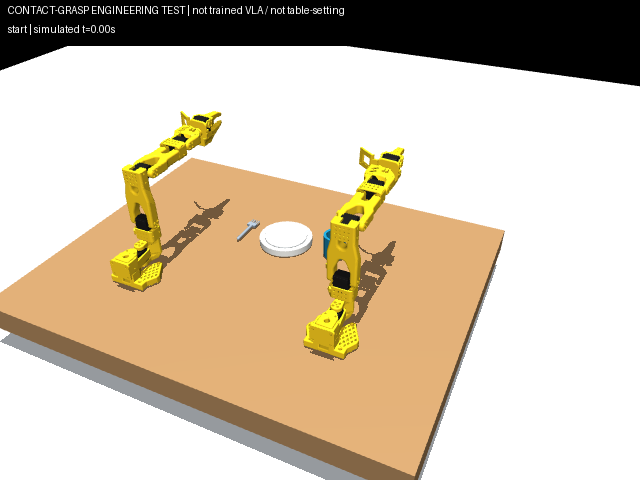

### Lifted — saved engineering snapshot

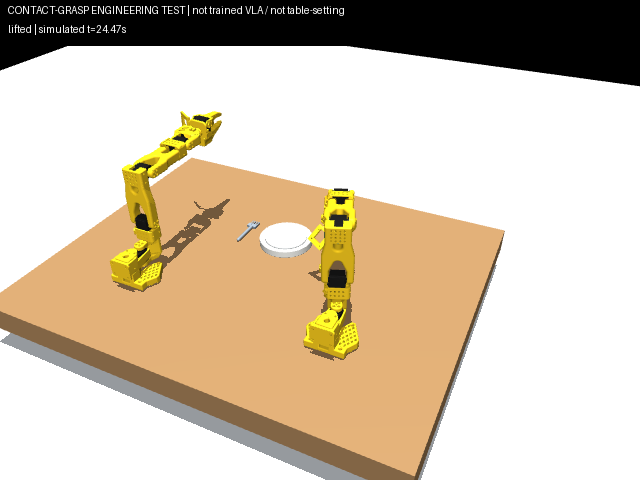

### Final — saved engineering snapshot

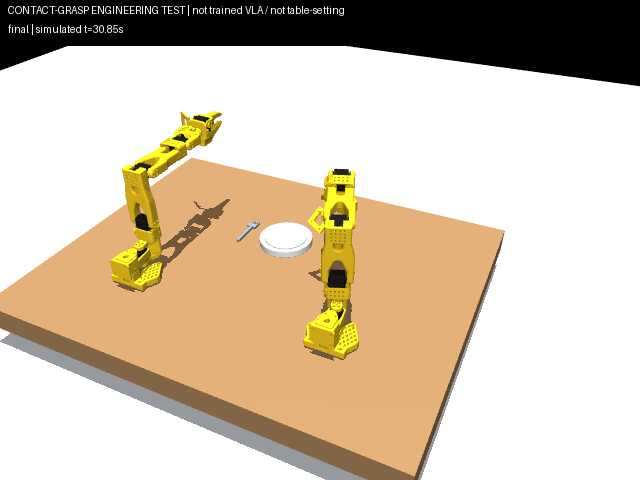


Recorded example: frame 154, simulated t=15.400 s
Instruction label: Lift the cup, hold it, and set it back on the table.


### top — saved pre-action observation

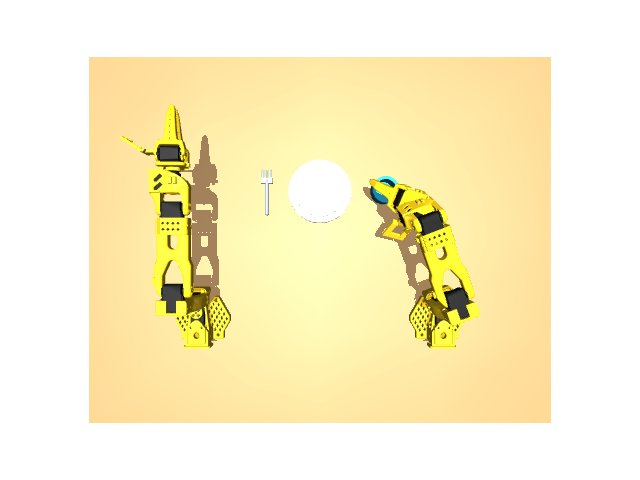

### right_wrist_cam — saved pre-action observation

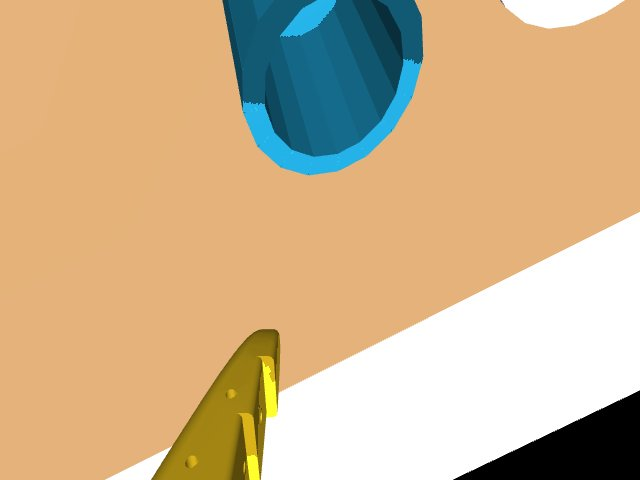


Display preparation time (s): 0.218
No new robot trial was launched. Source evidence was read, not changed.
This is an engineering demonstration, not trained-policy evaluation or complete table-setting.


In [2]:
# Default action: VIEW the completed recording. Do not rerun the robot just to see results.
from pathlib import Path

ROOT = Path(
    r"C:\Users\Fiza\Downloads"
    r"\TableGuard_Phase1_Python_Starter\TableGuard_Starter"
)
RUN_NAME = "20260912T235941Z_recording_0cd563"
MODE = "view_saved"  # Keep this for now. The alternative is "new_recording".

RESULT = run_workflow(ROOT, RUN_NAME, MODE)
ACTIVE_RUN = Path(RESULT["run"])
GRASP_REPORT_PATH = ACTIVE_RUN / "grasp_report.json"


## Only when you deliberately need a new recording

For now keep `MODE = "view_saved"`. You already reported a passed 309-record demonstration; displaying it does not require a new recording.

To run another trial later, set **only** `MODE = "new_recording"` in the results cell. That action:
1. Validates the selected successful source trial and its unchanged source scene.
2. Creates a new output directory and saves `record_data: true` explicitly; it does not reuse a stale notebook variable.
3. Runs the unchanged 56 regression checks (60-second limit), then starts the unchanged recording worker (300-second launcher limit).
4. Streams output to the notebook and `grasp.log`, retains launcher status, and displays that trial's actual results automatically on completion.

Interruption/timeout cleans up only this launcher's child. A lock prevents overlapping launches through this new workflow; older notebooks do not share that lock. Do not remove a lock while a worker is active. Failures and missing images remain failures/missing evidence. A new run is not a substitute for viewing a finished run.

### Reporting boundary
A 309-row manifest is one recorded demonstration, not 309 independent tasks. Basic checks establish readable JSON, counts, monotonic frame timestamps, camera references, and image-file existence; they do not audit every action chunk, decode every image, train a policy, or establish challenge compliance. The original controller uses simulator state and known geometry, not learned language/camera reasoning.

### Preparation validation
- Original 56 offline synthetic regressions: passed under Python 3.13.5.
- 21 workflow tests: passed, including read-only result loading, no child launch in view mode, missing/partial evidence handling, source preservation, image display with test fixtures, and dummy child timeout/interruption cleanup.
- The completed user's scene, raw recordings and JSON reports are not available in the preparation container. MuJoCo physics and Windows/Python 3.11 execution were not rerun here. Validation of notebook execution uses synthetic file/image fixtures, not new robot outcomes.

References: the uploaded `TableGuard_06B_Cup_Setdown_Fix_Portable(1).ipynb` is the code source. Launcher APIs: https://docs.python.org/3/library/subprocess.html . Inline display APIs: https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html . No network access is performed by view mode.
